<a href="https://colab.research.google.com/github/ManuelRomero2025/CienciasdeDatos1/blob/main/Coffee_sales_strategy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
#https://www.kaggle.com/code/masakane/coffee-sales-strategy-planning/notebook

In [ ]:
# Asegúrate de haber montado Google Drive previamente
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Leer el archivo desde Drive
df = pd.read_csv('/content/drive/MyDrive/LosLibertadores20252/20252P/Coffe_sales.csv')

## EDA (Exploratory Data Analysis)

In [ ]:
df.head()  # Comprobación de la cola del conjunto de datos

,hour_of_day,cash_type,money,coffee_name,Time_of_Day,Weekday,Month_name,Weekdaysort,Monthsort,Date,Time
0,10,card,38.7,Latte,Morning,Fri,Mar,5,3,2024-03-01,10:15:50.520000
1,12,card,38.7,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,12:19:22.539000
2,12,card,38.7,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,12:20:18.089000
3,13,card,28.9,Americano,Afternoon,Fri,Mar,5,3,2024-03-01,13:46:33.006000
4,13,card,38.7,Latte,Afternoon,Fri,Mar,5,3,2024-03-01,13:48:14.626000


In [ ]:
df.tail()  # Comprobación de la cola del conjunto de datos

,hour_of_day,cash_type,money,coffee_name,Time_of_Day,Weekday,Month_name,Weekdaysort,Monthsort,Date,Time
3542,10,card,35.76,Cappuccino,Morning,Sun,Mar,7,3,2025-03-23,10:34:54.894000
3543,14,card,35.76,Cocoa,Afternoon,Sun,Mar,7,3,2025-03-23,14:43:37.362000
3544,14,card,35.76,Cocoa,Afternoon,Sun,Mar,7,3,2025-03-23,14:44:16.864000
3545,15,card,25.96,Americano,Afternoon,Sun,Mar,7,3,2025-03-23,15:47:28.723000
3546,18,card,35.76,Latte,Night,Sun,Mar,7,3,2025-03-23,18:11:38.635000


In [ ]:
df.info() # Comprobando la información del conjunto de datos

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3547 entries, 0 to 3546
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   hour_of_day  3547 non-null   int64  
 1   cash_type    3547 non-null   object 
 2   money        3547 non-null   float64
 3   coffee_name  3547 non-null   object 
 4   Time_of_Day  3547 non-null   object 
 5   Weekday      3547 non-null   object 
 6   Month_name   3547 non-null   object 
 7   Weekdaysort  3547 non-null   int64  
 8   Monthsort    3547 non-null   int64  
 9   Date         3547 non-null   object 
 10  Time         3547 non-null   object 
dtypes: float64(1), int64(3), object(7)
memory usage: 304.9+ KB


In [ ]:
df.isnull().sum() # Comprobando el valor isnull del conjunto de datos

,0
hour_of_day,0
cash_type,0
money,0
coffee_name,0
Time_of_Day,0
Weekday,0
Month_name,0
Weekdaysort,0
Monthsort,0
Date,0


In [ ]:
df.describe()   # describir el conjunto de datos

,hour_of_day,money,Weekdaysort,Monthsort
count,3547.000000,3547.000000,3547.000000,3547.000000
mean,14.185791,31.645216,3.845785,6.453905
std,4.234010,4.877754,1.971501,3.500754
min,6.000000,18.120000,1.000000,1.000000
25%,10.000000,27.920000,2.000000,3.000000
50%,14.000000,32.820000,4.000000,7.000000
75%,18.000000,35.760000,6.000000,10.000000
max,22.000000,38.700000,7.000000,12.000000


In [ ]:
df.duplicated() # Comprobación de valores duplicados en el conjunto de datos

,0
0,False
1,False
2,False
3,False
4,False
...,...
3542,False
3543,False
3544,False
3545,False


In [ ]:
df.dtypes # Comprobando los tipos de datos del conjunto de datos

,0
hour_of_day,int64
cash_type,object
money,float64
coffee_name,object
Time_of_Day,object
Weekday,object
Month_name,object
Weekdaysort,int64
Monthsort,int64
Date,object


In [ ]:
df.nunique() # Comprobación de la unicidad del conjunto de datos

,0
hour_of_day,17
cash_type,1
money,13
coffee_name,8
Time_of_Day,3
Weekday,7
Month_name,12
Weekdaysort,7
Monthsort,12
Date,381


In [ ]:
df.columns # Comprobando las columnas del conjunto de datos

Index(['hour_of_day', 'cash_type', 'money', 'coffee_name', 'Time_of_Day',
       'Weekday', 'Month_name', 'Weekdaysort', 'Monthsort', 'Date', 'Time'],
      dtype='object')

In [ ]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

In [ ]:
numeric_columns = ['hour_of_day', 'money', 'Weekdaysort', 'Monthsort']
df[numeric_columns] = df[numeric_columns].apply(pd.to_numeric, errors='coerce')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3547 entries, 0 to 3546
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   hour_of_day  3547 non-null   int64         
 1   cash_type    3547 non-null   object        
 2   money        3547 non-null   float64       
 3   coffee_name  3547 non-null   object        
 4   Time_of_Day  3547 non-null   object        
 5   Weekday      3547 non-null   object        
 6   Month_name   3547 non-null   object        
 7   Weekdaysort  3547 non-null   int64         
 8   Monthsort    3547 non-null   int64         
 9   Date         3547 non-null   datetime64[ns]
 10  Time         3547 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(3), object(6)
memory usage: 304.9+ KB


In [ ]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

In [ ]:
df['Date'].isna().sum()

np.int64(0)

In [ ]:
numeric_columns = ['hour_of_day', 'money', 'Weekdaysort', 'Monthsort']
df[numeric_columns] = df[numeric_columns].apply(pd.to_numeric, errors='coerce')

# Check for missing values in other columns
print(df.isna().sum())

hour_of_day    0
cash_type      0
money          0
coffee_name    0
Time_of_Day    0
Weekday        0
Month_name     0
Weekdaysort    0
Monthsort      0
Date           0
Time           0
dtype: int64


In [ ]:
df.head()

,hour_of_day,cash_type,money,coffee_name,Time_of_Day,Weekday,Month_name,Weekdaysort,Monthsort,Date,Time
0,10,card,38.7,Latte,Morning,Fri,Mar,5,3,2024-03-01,10:15:50.520000
1,12,card,38.7,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,12:19:22.539000
2,12,card,38.7,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,12:20:18.089000
3,13,card,28.9,Americano,Afternoon,Fri,Mar,5,3,2024-03-01,13:46:33.006000
4,13,card,38.7,Latte,Afternoon,Fri,Mar,5,3,2024-03-01,13:48:14.626000


In [ ]:
numeric_df = df.select_dtypes(include=[np.number])
print(numeric_df.describe())

       hour_of_day        money  Weekdaysort    Monthsort
count  3547.000000  3547.000000  3547.000000  3547.000000
mean     14.185791    31.645216     3.845785     6.453905
std       4.234010     4.877754     1.971501     3.500754
min       6.000000    18.120000     1.000000     1.000000
25%      10.000000    27.920000     2.000000     3.000000
50%      14.000000    32.820000     4.000000     7.000000
75%      18.000000    35.760000     6.000000    10.000000
max      22.000000    38.700000     7.000000    12.000000


/tmp/ipython-input-3504233659.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Time_of_Day', y='money', data=df, palette='Pastel1')


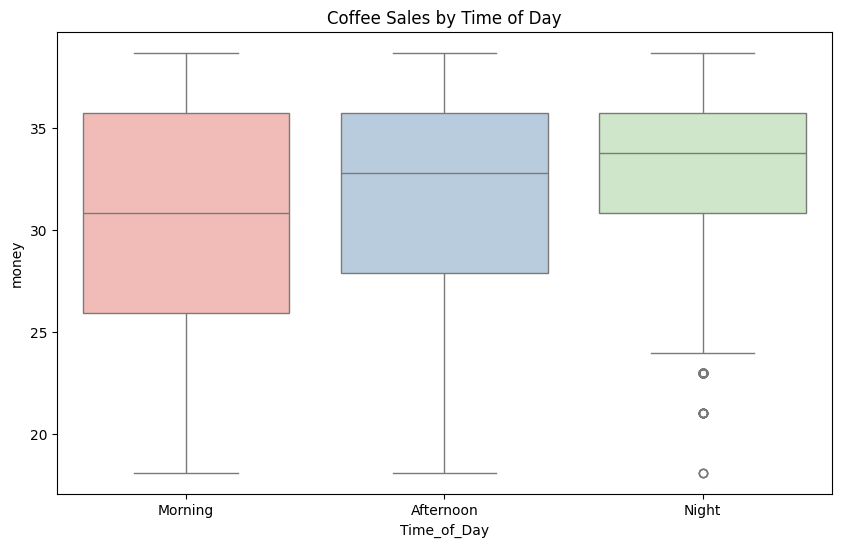

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Time_of_Day', y='money', data=df, palette='Pastel1')
plt.title('Coffee Sales by Time of Day')
plt.show()

## Analysis by hour of the week（Coffee)

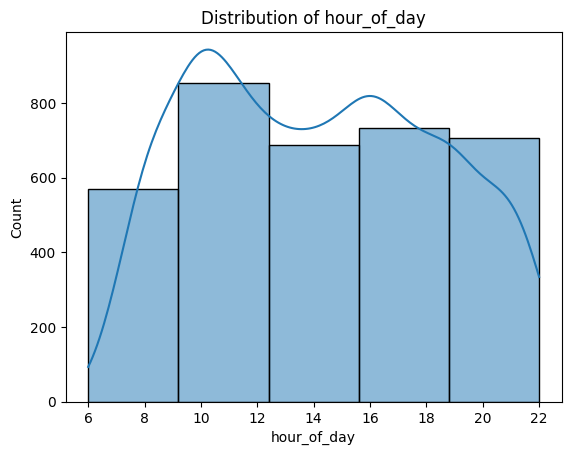

In [ ]:
sns.histplot(data=df, x="hour_of_day", bins=5,kde=True)
plt.title("Distribution of hour_of_day")
plt.xlabel("hour_of_day")
plt.ylabel("Count")
plt.show()

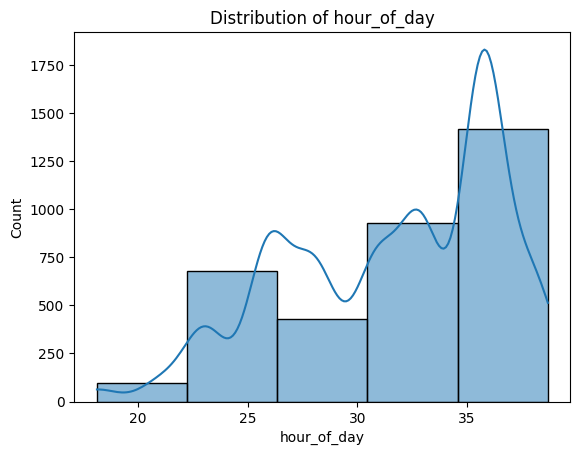

In [ ]:
sns.histplot(data=df, x="money",bins=5, kde=True)
plt.title("Distribution of hour_of_day")
plt.xlabel("hour_of_day")
plt.ylabel("Count")
plt.show()

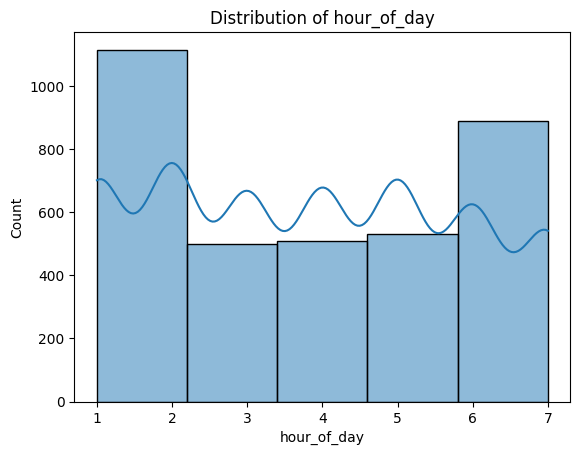

In [ ]:
sns.histplot(data=df, x="Weekdaysort",bins=5, kde=True)
plt.title("Distribution of hour_of_day")
plt.xlabel("hour_of_day")
plt.ylabel("Count")
plt.show()

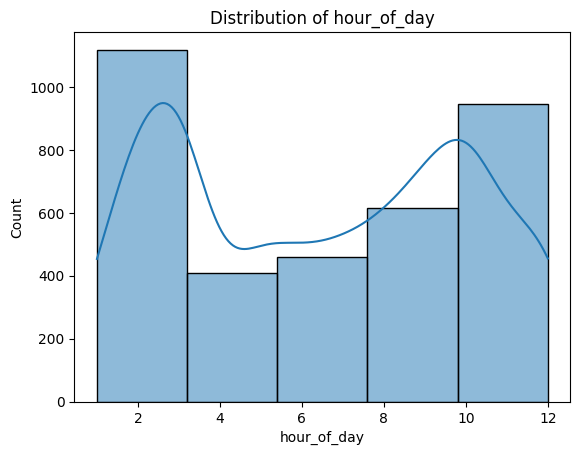

In [ ]:
sns.histplot(data=df, x="Monthsort",bins=5, kde=True)
plt.title("Distribution of hour_of_day")
plt.xlabel("hour_of_day")
plt.ylabel("Count")
plt.show()

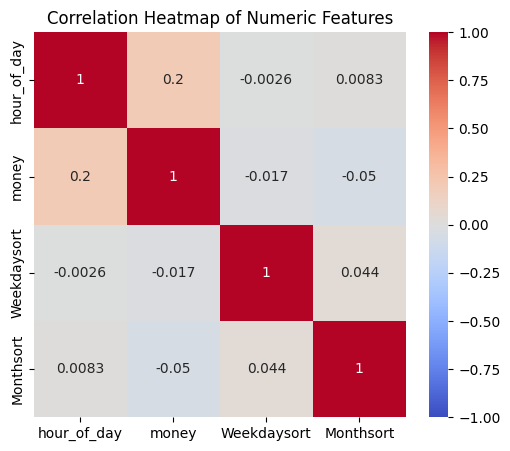

In [ ]:
# Seleccionar solo columnas numéricas
numeric_df = df[["hour_of_day", "money", "Weekdaysort", "Monthsort"]]

# Matriz de correlaciones
corr = numeric_df.corr()

# Heatmap simple
plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

## Analysis by day of the week（Coffee)

In [ ]:
lista_dias = df["Weekday"].unique().tolist()
print(lista_dias)

['Fri', 'Sat', 'Sun', 'Mon', 'Tue', 'Wed', 'Thu']


In [ ]:
lista_bebidas = df["coffee_name"].unique().tolist()
print(lista_bebidas)

['Latte', 'Hot Chocolate', 'Americano', 'Americano with Milk', 'Cocoa', 'Cortado', 'Espresso', 'Cappuccino']


In [ ]:
lista_jornada = df["Time_of_Day"].unique().tolist()
print(lista_jornada)

['Morning', 'Afternoon', 'Night']


In [ ]:
lista_meses = df["Month_name"].unique().tolist()
print(lista_meses)


['Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', 'Jan', 'Feb']


In [ ]:
# Filtrar solo las filas donde el café vendido es "Americano"
americano_df = df[df["coffee_name"] == "Americano"]

# Contar ventas por día de la semana
counts = americano_df["Weekday"].value_counts().reindex(
    ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
)

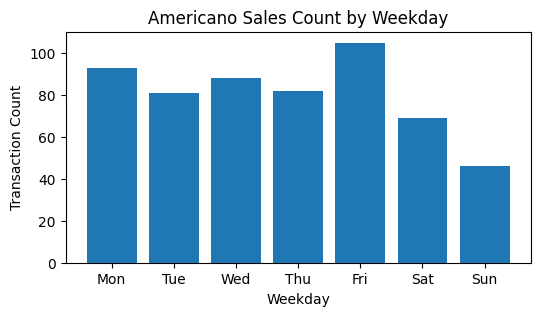

In [ ]:
# Gráfica
plt.figure(figsize=(6,3))
plt.bar(counts.index, counts.values)
plt.title("Americano Sales Count by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Transaction Count")
plt.show()

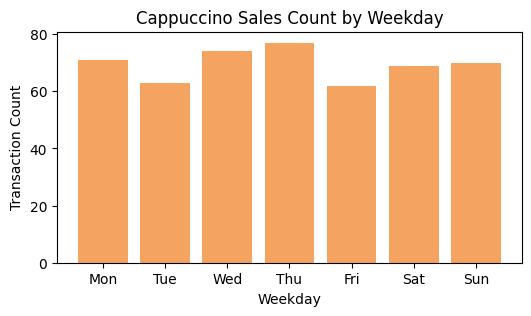

In [ ]:
# Filtrar el café "Americano with Milk"
df_cap = df[df["coffee_name"] == "Cappuccino"]

# Contar ventas por día de la semana
counts = df_cap["Weekday"].value_counts().reindex(
    ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
)

# Gráfica
plt.figure(figsize=(6,3))
plt.bar(counts.index, counts.values, color="sandybrown")
plt.title("Cappuccino Sales Count by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Transaction Count")
plt.show()

In [ ]:
# Filtrar el café "Americano with Milk"
df_cap = df[df["coffee_name"] == "Cappuccino"]

# Contar ventas por día de la semana
counts = df_cap["Weekday"].value_counts().reindex(
    ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
)

# Gráfica
plt.figure(figsize=(6,3))
plt.bar(counts.index, counts.values, color="sandybrown")
plt.title("Cappuccino Sales Count by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Transaction Count")
plt.show()

## Analysis by Time of Day（Coffee)

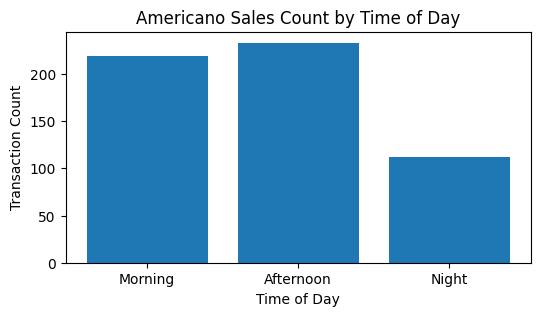

In [ ]:
# Filtrar solo Americano
df_ame = df[df["coffee_name"] == "Americano"]

# Contar ventas por Time_of_Day
counts = df_ame["Time_of_Day"].value_counts().reindex(
    ["Morning", "Afternoon", "Night"]
)

# Gráfica
plt.figure(figsize=(6,3))
plt.bar(counts.index, counts.values)
plt.title("Americano Sales Count by Time of Day")
plt.xlabel("Time of Day")
plt.ylabel("Transaction Count")
plt.show()

## Analysis by Month（Coffee)

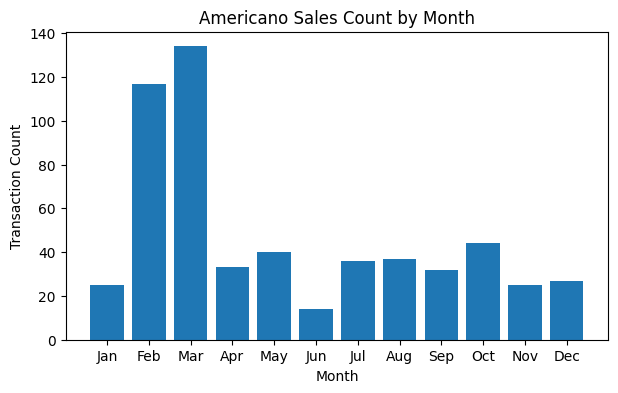

In [ ]:
# Filtrar solo Americano
df_ame = df[df["coffee_name"] == "Americano"]

# Orden correcto de los meses
orden_meses = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

# Contar ventas por mes
counts = df_ame["Month_name"].value_counts().reindex(orden_meses)

# Gráfica
plt.figure(figsize=(7,4))
plt.bar(counts.index, counts.values)
plt.title("Americano Sales Count by Month")
plt.xlabel("Month")
plt.ylabel("Transaction Count")
plt.show()

In [ ]:
# 1. Asegurar que Date sea tipo fecha
df["Date"] = pd.to_datetime(df["Date"])

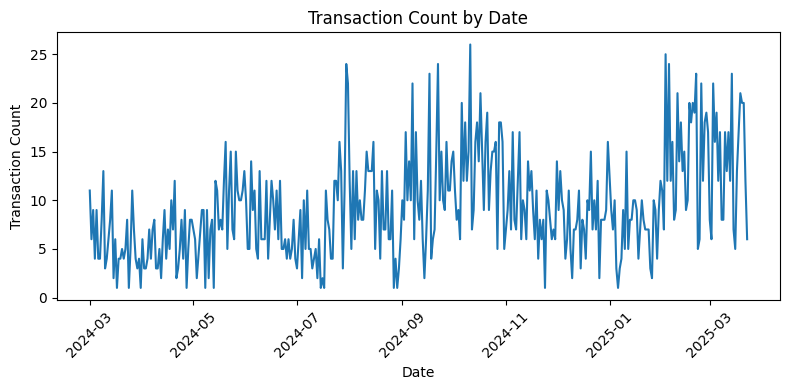

In [ ]:
# Contar cuántas ventas hubo cada día
ventas_por_dia = df["Date"].value_counts().sort_index()

plt.figure(figsize=(8,4))
plt.plot(ventas_por_dia.index, ventas_por_dia.values)
plt.title("Transaction Count by Date")
plt.xlabel("Date")
plt.ylabel("Transaction Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


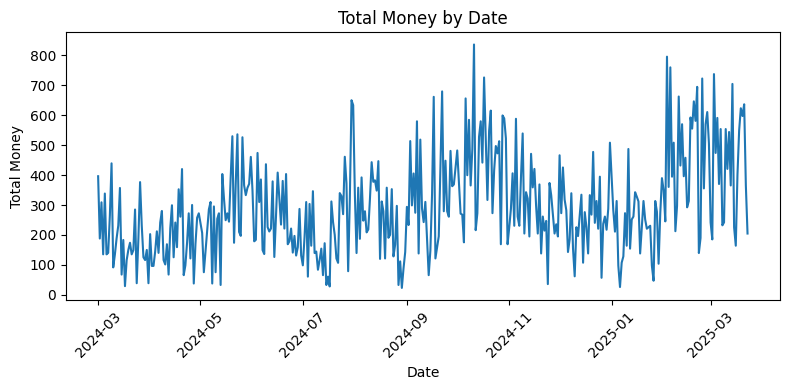

In [ ]:
# Sumar el dinero vendido por día
money_por_dia = df.groupby("Date")["money"].sum()

plt.figure(figsize=(8,4))
plt.plot(money_por_dia.index, money_por_dia.values)
plt.title("Total Money by Date")
plt.xlabel("Date")
plt.ylabel("Total Money")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


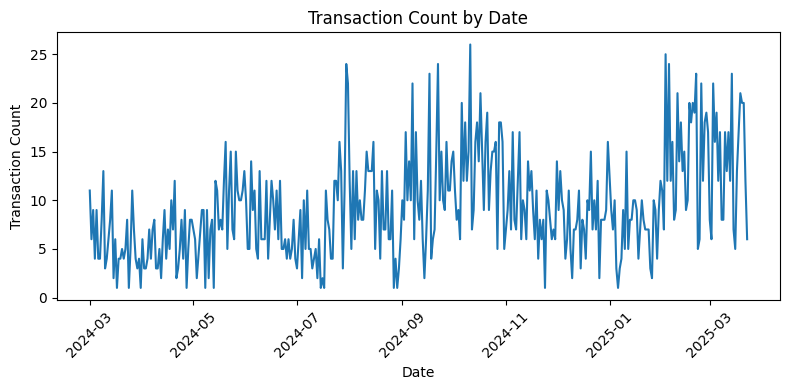

In [ ]:
# Asegurar tipo fecha
df["Date"] = pd.to_datetime(df["Date"])
# Número de transacciones por fecha
ventas_por_dia = df["Date"].value_counts().sort_index()

plt.figure(figsize=(8,4))
plt.plot(ventas_por_dia.index, ventas_por_dia.values)
plt.title("Transaction Count by Date")
plt.xlabel("Date")
plt.ylabel("Transaction Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


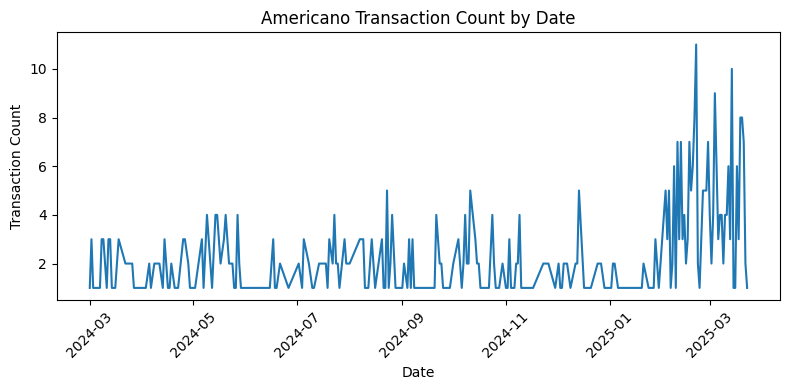

In [ ]:
# Filtrar Americano
df_ame = df[df["coffee_name"] == "Americano"]

# Conteo de transacciones de Americano por fecha
ame_por_dia = df_ame["Date"].value_counts().sort_index()

plt.figure(figsize=(8,4))
plt.plot(ame_por_dia.index, ame_por_dia.values)
plt.title("Americano Transaction Count by Date")
plt.xlabel("Date")
plt.ylabel("Transaction Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


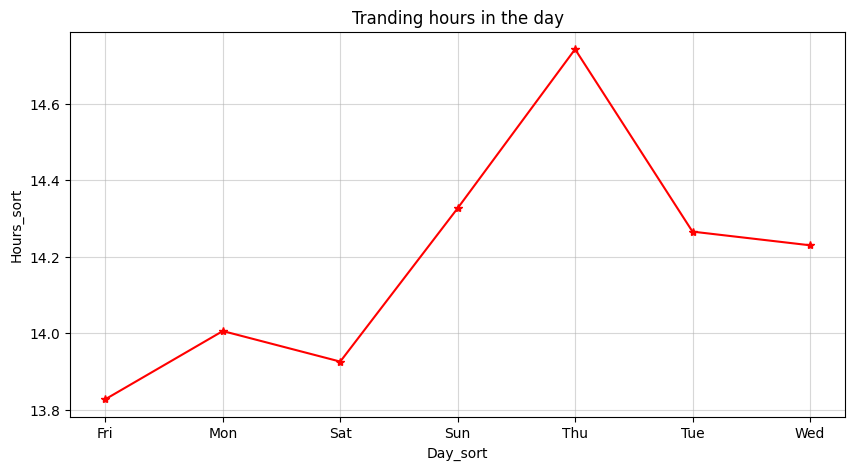

In [ ]:
plt.figure(figsize=(10,5))
df1 = df.groupby("Weekday")["hour_of_day"].mean()
plt.plot(df1.index, df1.values, marker='*', color="red")
plt.title("Tranding hours in the day")
plt.xlabel("Day_sort")
plt.ylabel("Hours_sort")
plt.grid(True, alpha=0.5)
plt.show()

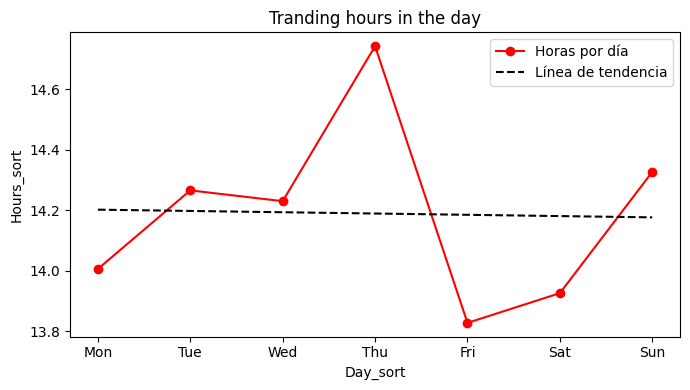

In [ ]:

# Orden correcto de días
orden_dias = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

# Reordenar
df_sort = df_sort.set_index("Day_sort").loc[orden_dias].reset_index()

x_labels = df_sort["Day_sort"]
y = df_sort["Hours_sort"].values

# convertir eje x a números
x = np.arange(len(x_labels))

# tendencia
a, b = np.polyfit(x, y, 1)
y_trend = a * x + b

plt.figure(figsize=(7,4))

# línea principal
plt.plot(x_labels, y, "r-o", label="Horas por día")

# línea de tendencia
plt.plot(x_labels, y_trend, "k--", label="Línea de tendencia")

plt.title("Tranding hours in the day")
plt.xlabel("Day_sort")
plt.ylabel("Hours_sort")
plt.legend()
plt.tight_layout()
plt.show()


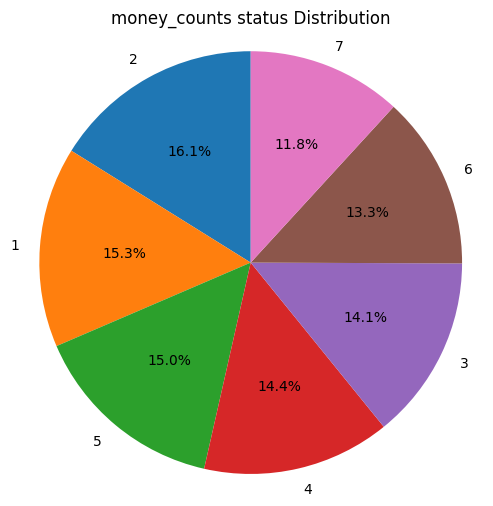

In [ ]:
# step 4: pie Chart - Distribution of Furnishing statua
money_counts = df["Weekdaysort"].value_counts()

#figsize=(6,6) means the figure will be 6 inches wide and 6 inches tall (a squrae).
plt.figure(figsize=(6,6))

plt.pie(money_counts, labels=money_counts.index,autopct="%1.1f%%",startangle=90)
plt.title("money_counts status Distribution")
plt.axis("equal") #plt.axis("equal") ="keep the pie chart round, not ovel.
plt.show()

<Figure size 1000x500 with 0 Axes>

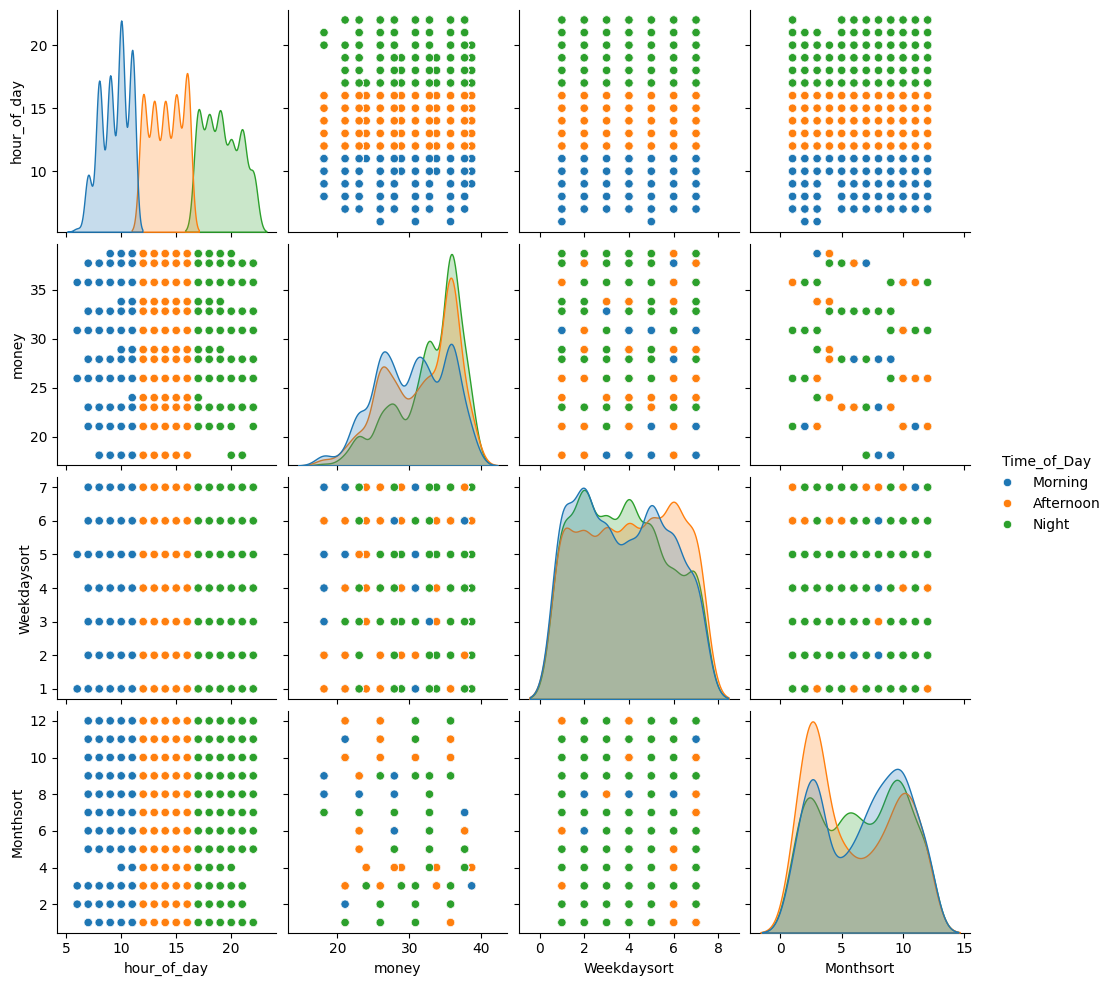

In [ ]:
plt.figure(figsize=(10,5))
sns.pairplot(df,hue= "Time_of_Day")
plt.show()

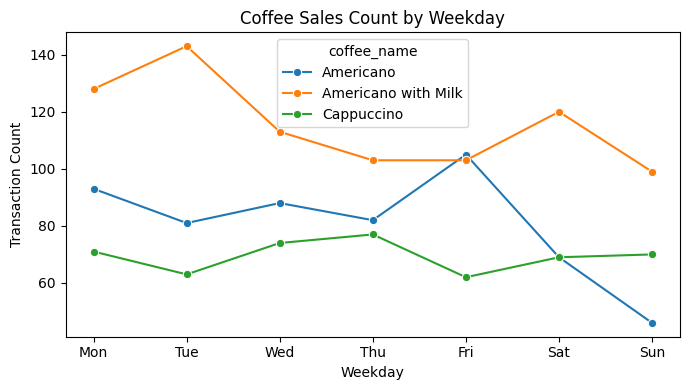

In [ ]:
 #Elegimos algunos cafés para comparar
cafes = ["Americano", "Americano with Milk", "Cappuccino"]

df_sub = df[df["coffee_name"].isin(cafes)]

# Agrupamos: transacciones por día y tipo de café
tabla = (df_sub
         .groupby(["Weekdaysort", "Weekday", "coffee_name"])
         .size()
         .reset_index(name="transactions"))

# Ordenar por el orden numérico del día
tabla = tabla.sort_values("Weekdaysort")

# Gráfica de líneas con seaborn
plt.figure(figsize=(7,4))
sns.lineplot(
    data=tabla,
    x="Weekday",            # nombre del día en el eje X (Mon, Tue, ...)
    y="transactions",       # número de transacciones
    hue="coffee_name",      # una línea por cada café
    marker="o"
)

plt.title("Coffee Sales Count by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Transaction Count")
plt.tight_layout()
plt.show()

## Ventas por tipo de café (ranking general)

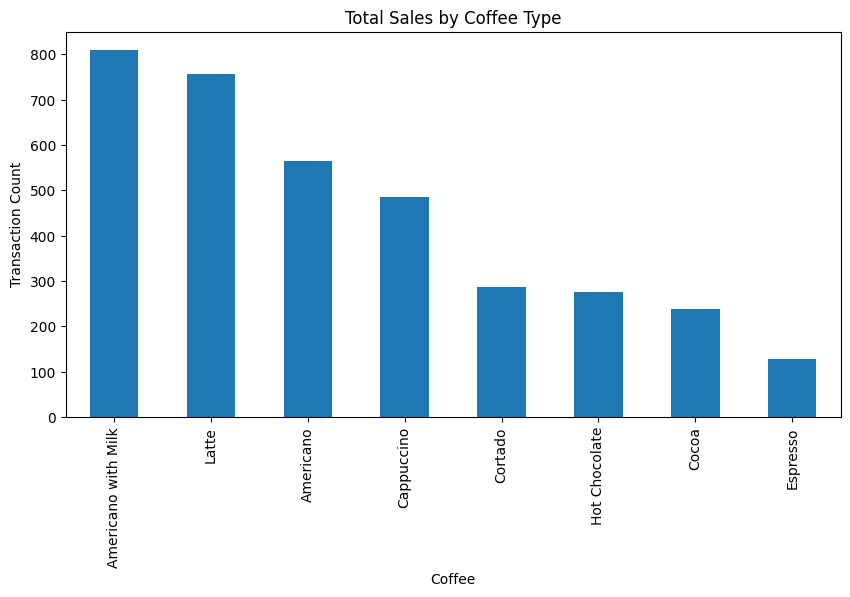

In [ ]:
plt.figure(figsize=(10,5))
df["coffee_name"].value_counts().plot(kind="bar")
plt.title("Total Sales by Coffee Type")
plt.xlabel("Coffee")
plt.ylabel("Transaction Count")
plt.show()


# Ingresos totales por hora del día

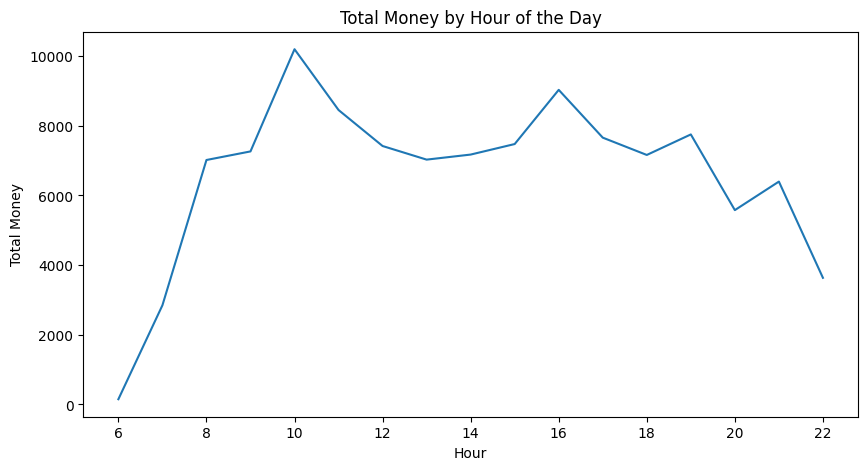

In [ ]:
plt.figure(figsize=(10,5))
df.groupby("hour_of_day")["money"].sum().plot(kind="line")
plt.title("Total Money by Hour of the Day")
plt.xlabel("Hour")
plt.ylabel("Total Money")
plt.show()


# Heatmap (Hora vs Tipo de Café)

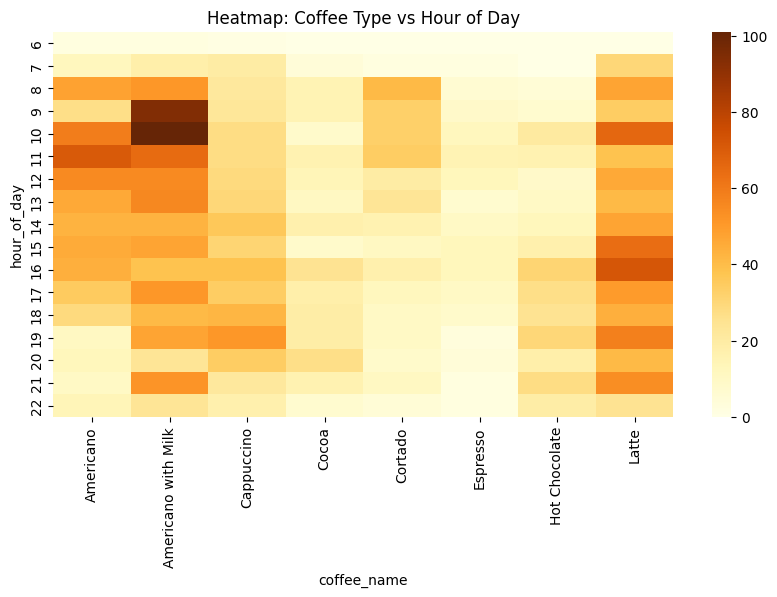

In [ ]:
plt.figure(figsize=(10,5))
tabla = pd.crosstab(df["hour_of_day"], df["coffee_name"])
sns.heatmap(tabla, cmap="YlOrBr")
plt.title("Heatmap: Coffee Type vs Hour of Day")
plt.show()

## Ventas por mes (todas las bebidas juntas)

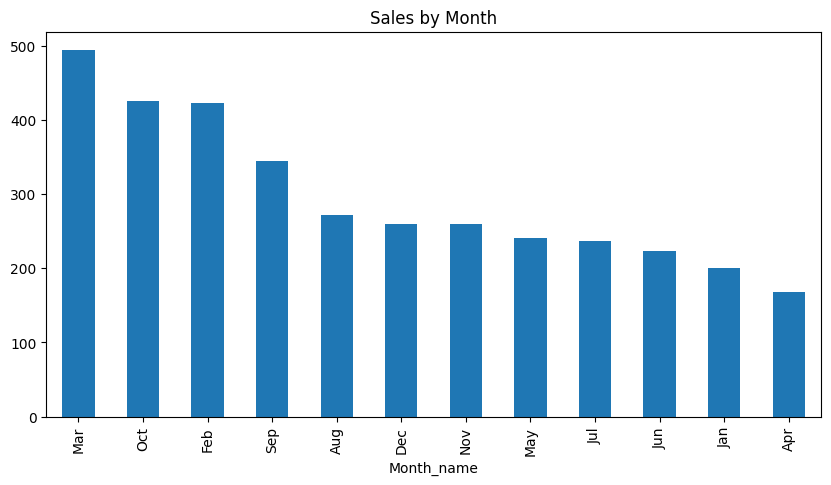

In [ ]:
plt.figure(figsize=(10,5))
df["Month_name"].value_counts().plot(kind="bar")
plt.title("Sales by Month")
plt.show()


## Ingresos por mes


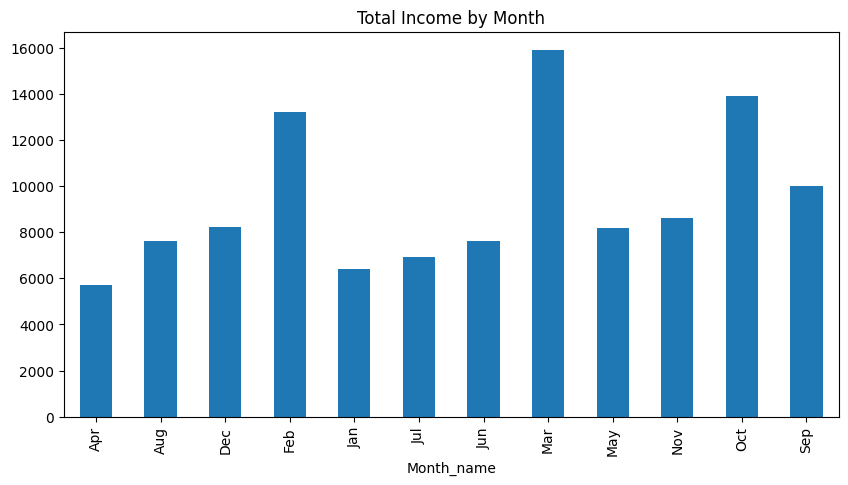

In [ ]:
plt.figure(figsize=(10,5))
df.groupby("Month_name")["money"].sum().plot(kind="bar")
plt.title("Total Income by Month")
plt.show()


## Sales Funnel: Morning → Afternoon → Night

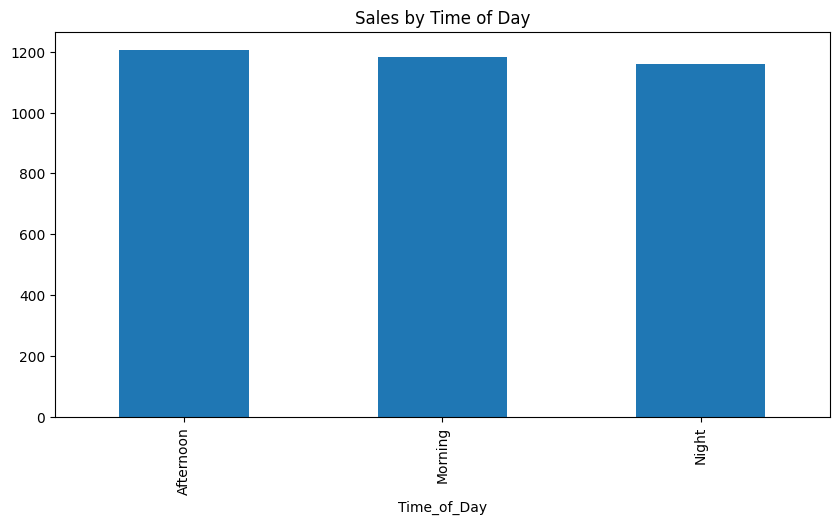

In [ ]:
plt.figure(figsize=(10,5))
df["Time_of_Day"].value_counts().plot(kind="bar")
plt.title("Sales by Time of Day")
plt.show()


## Ventas por día de la semana (todos los cafés)

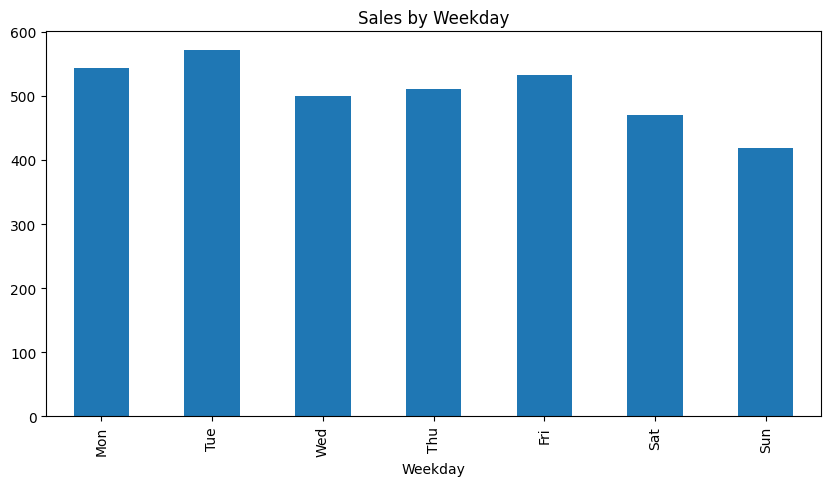

In [ ]:
plt.figure(figsize=(10,5))
df["Weekday"].value_counts().reindex(["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]).plot(kind="bar")
plt.title("Sales by Weekday")
plt.show()


## Ventas por bebida y por día (gráfica de líneas múltiples)

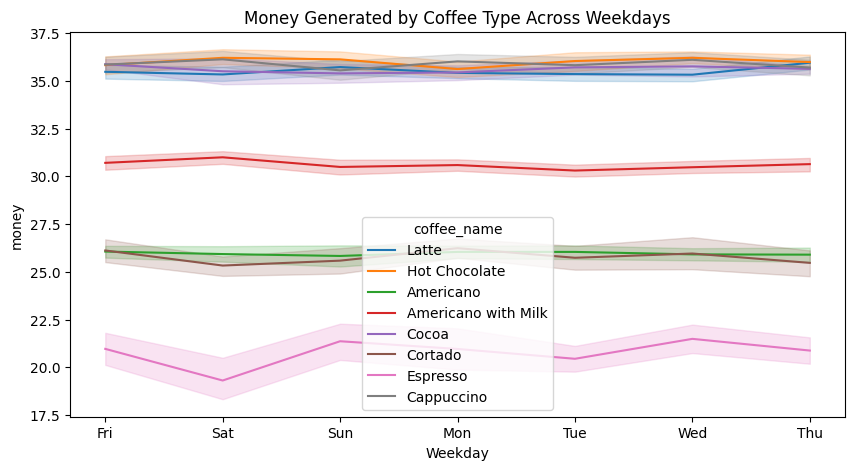

In [ ]:
plt.figure(figsize=(10,5))
sns.lineplot(data=df, x="Weekday", y="money", hue="coffee_name")
plt.title("Money Generated by Coffee Type Across Weekdays")
plt.show()


## Top ingresos por café (ranking)

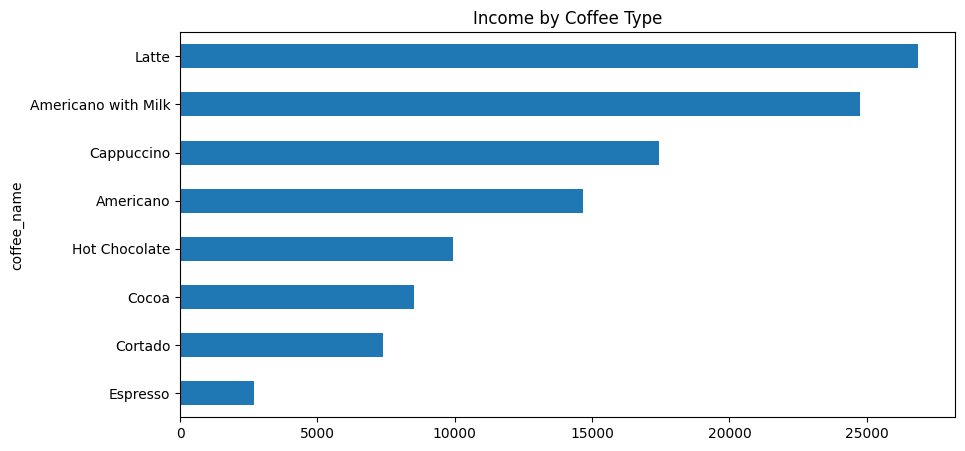

In [ ]:
plt.figure(figsize=(10,5))
df.groupby("coffee_name")["money"].sum().sort_values().plot(kind="barh")
plt.title("Income by Coffee Type")
plt.show()


## Boxplot del dinero por bebida

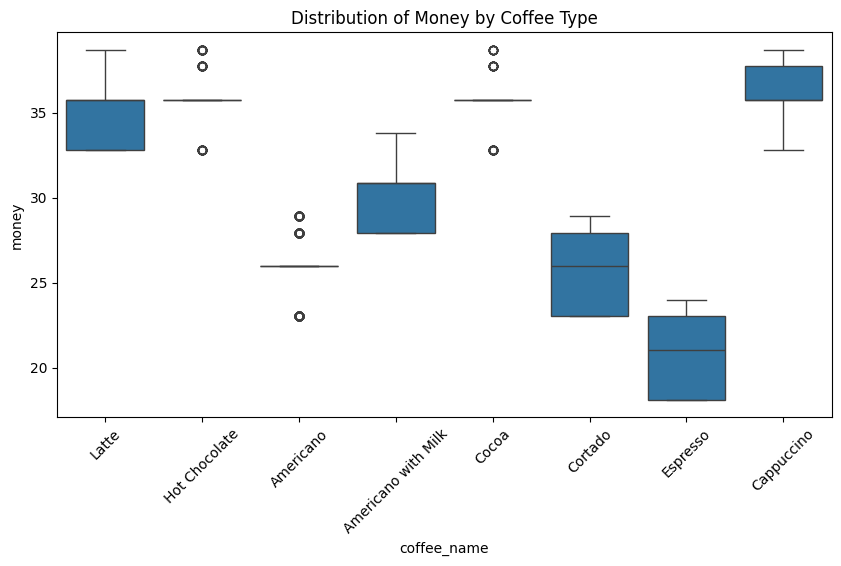

In [ ]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x="coffee_name", y="money")
plt.title("Distribution of Money by Coffee Type")
plt.xticks(rotation=45)
plt.show()


# Atros analisis

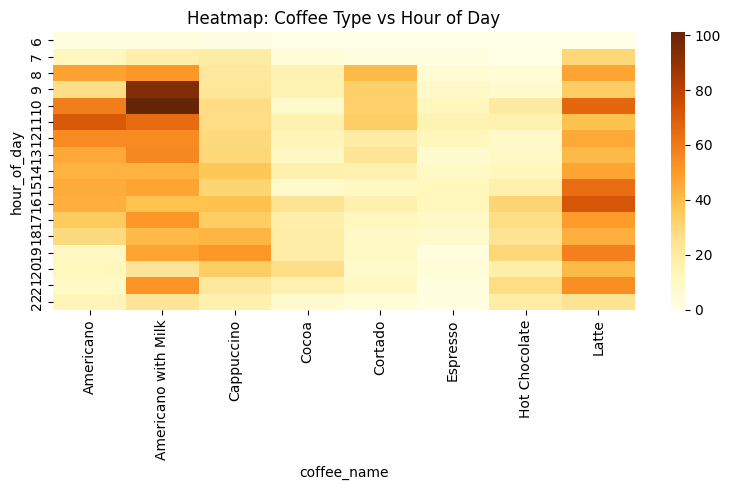

In [ ]:
# Ensure time formats
df["Date"] = pd.to_datetime(df["Date"])

# 1) Heatmap Coffee vs Hour
plt.figure(figsize=(8,5))
pivot1 = pd.crosstab(df["hour_of_day"], df["coffee_name"])
sns.heatmap(pivot1, cmap="YlOrBr")
plt.title("Heatmap: Coffee Type vs Hour of Day")
plt.tight_layout()
plt.show()



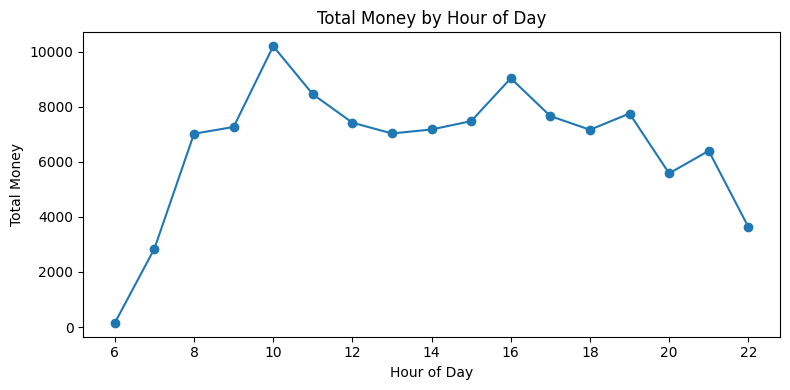

In [ ]:
# 2) Ingresos por hora
plt.figure(figsize=(8,4))
df.groupby("hour_of_day")["money"].sum().plot(kind="line", marker="o")
plt.title("Total Money by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Total Money")
plt.tight_layout()
plt.show()


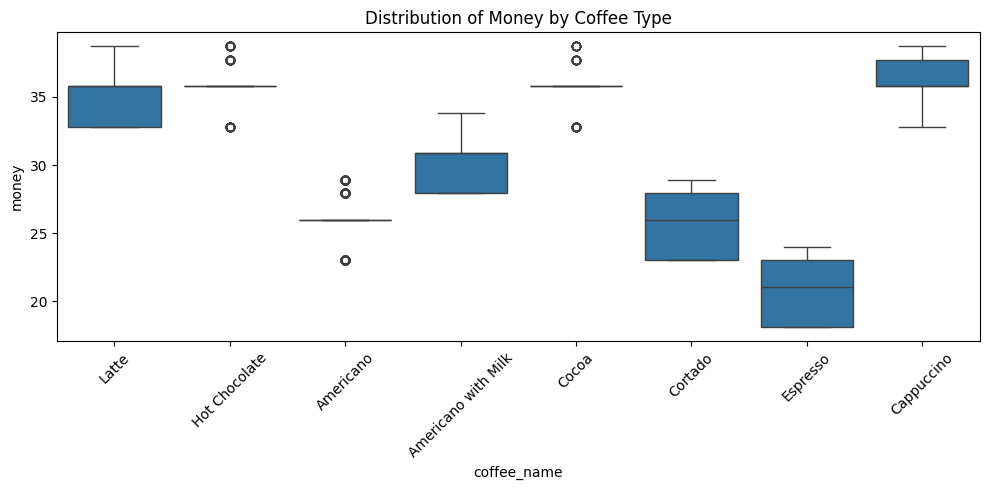

In [ ]:

# 3) Boxplot money by drink
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x="coffee_name", y="money")
plt.xticks(rotation=45)
plt.title("Distribution of Money by Coffee Type")
plt.tight_layout()
plt.show()

<Figure size 900x500 with 0 Axes>

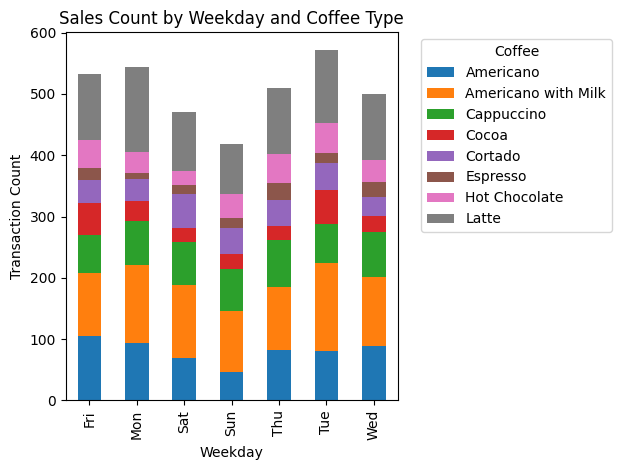

In [ ]:
tabla = pd.crosstab(df["Weekday"], df["coffee_name"])

plt.figure(figsize=(9,5))
tabla.plot(kind="bar", stacked=True)
plt.title("Sales Count by Weekday and Coffee Type")
plt.xlabel("Weekday")
plt.ylabel("Transaction Count")
plt.legend(title="Coffee", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


##  Barras cruzadas (Weekday vs cash_type)

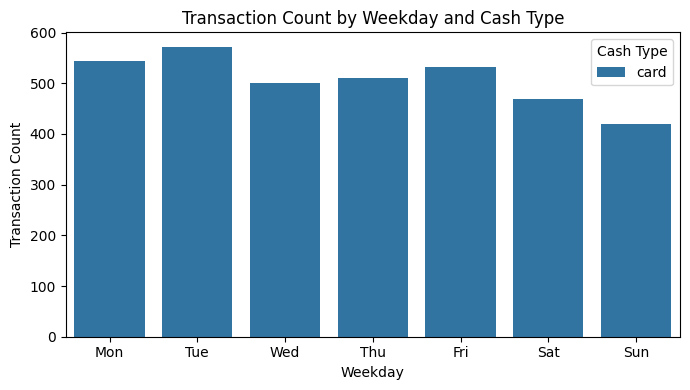

In [ ]:
import pandas as pd

orden_dias = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

df["Weekday"] = pd.Categorical(df["Weekday"],
                               categories=orden_dias,
                               ordered=True)

plt.figure(figsize=(7,4))
sns.countplot(data=df, x="Weekday", hue="cash_type")
plt.title("Transaction Count by Weekday and Cash Type")
plt.xlabel("Weekday")
plt.ylabel("Transaction Count")
plt.legend(title="Cash Type")
plt.tight_layout()
plt.show()


## Barras apiladas (stacked) con crosstab (Weekday vs coffee_name)

<Figure size 900x500 with 0 Axes>

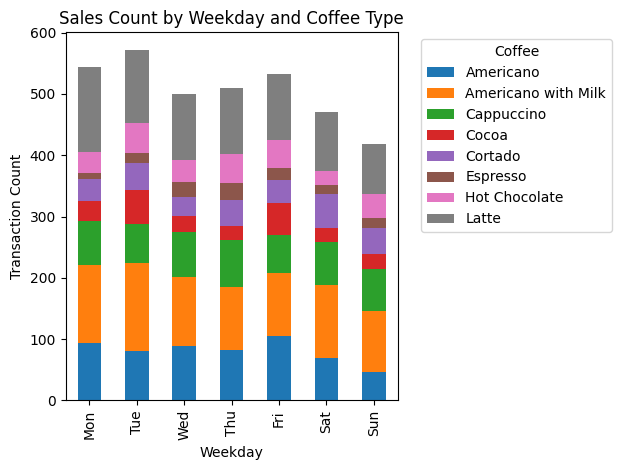

In [ ]:
tabla = pd.crosstab(df["Weekday"], df["coffee_name"])
tabla = tabla.reindex(orden_dias)  # por si acaso

plt.figure(figsize=(9,5))
tabla.plot(kind="bar", stacked=True)
plt.title("Sales Count by Weekday and Coffee Type")
plt.xlabel("Weekday")
plt.ylabel("Transaction Count")
plt.legend(title="Coffee", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


## Barras apiladas normalizadas

<Figure size 1000x500 with 0 Axes>

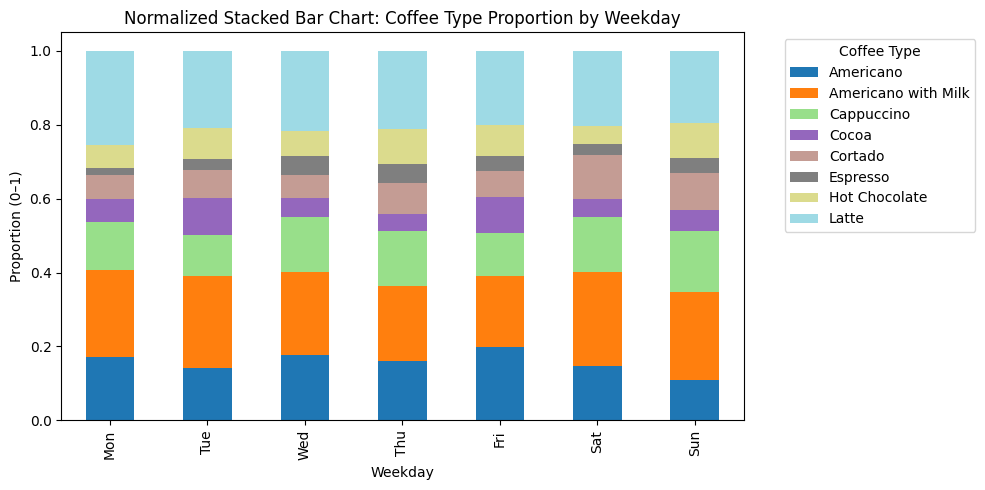

In [ ]:
# Normalize stacked bars: Weekday × Coffee_name
tabla = pd.crosstab(df["Weekday"], df["coffee_name"], normalize="index")

# Correct weekday order
order_days = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
tabla = tabla.reindex(order_days)

# Plot
plt.figure(figsize=(10,5))
tabla.plot(kind="bar", stacked=True, figsize=(10,5), colormap="tab20")

plt.title("Normalized Stacked Bar Chart: Coffee Type Proportion by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Proportion (0–1)")
plt.legend(title="Coffee Type", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


## Barras cruzadas para cafés seleccionados (Americano, Americano with Milk, Cappuccino)

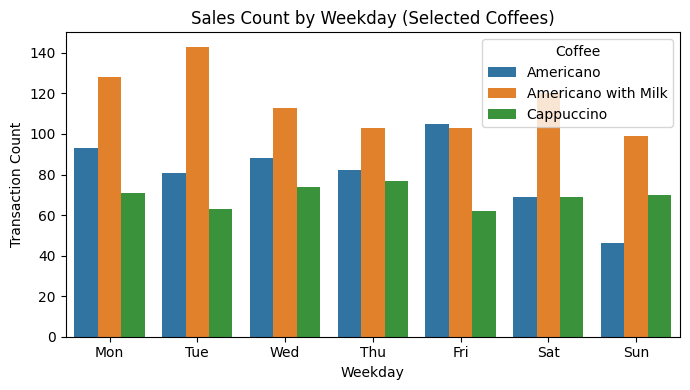

In [ ]:
cafes = ["Americano", "Americano with Milk", "Cappuccino"]
df_sub = df[df["coffee_name"].isin(cafes)]

plt.figure(figsize=(7,4))
sns.countplot(data=df_sub, x="Weekday", hue="coffee_name")
plt.title("Sales Count by Weekday (Selected Coffees)")
plt.xlabel("Weekday")
plt.ylabel("Transaction Count")
plt.legend(title="Coffee")
plt.tight_layout()
plt.show()


## Gráfico de Pareto (20% cafés generan 80% ingresos)

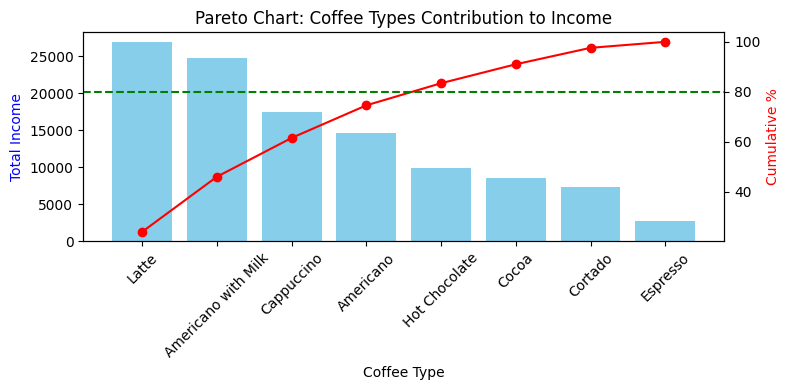

In [ ]:
# Compute Pareto data
pareto = df.groupby("coffee_name")["money"].sum().sort_values(ascending=False)
cumperc = pareto.cumsum() / pareto.sum() * 100

# Prepare figure
fig, ax1 = plt.subplots(figsize=(8,4))

# Bar plot
ax1.bar(pareto.index, pareto.values, color="skyblue")
ax1.set_xlabel("Coffee Type")
ax1.set_ylabel("Total Income", color="blue")
ax1.tick_params(axis="x", rotation=45)

# Line plot (cumulative percentage)
ax2 = ax1.twinx()
ax2.plot(pareto.index, cumperc.values, color="red", marker="o")
ax2.set_ylabel("Cumulative %", color="red")
ax2.axhline(80, color="green", linestyle="--")  # 80% reference line

plt.title("Pareto Chart: Coffee Types Contribution to Income")
plt.tight_layout()
plt.show()

## Heatmap hora × café × día

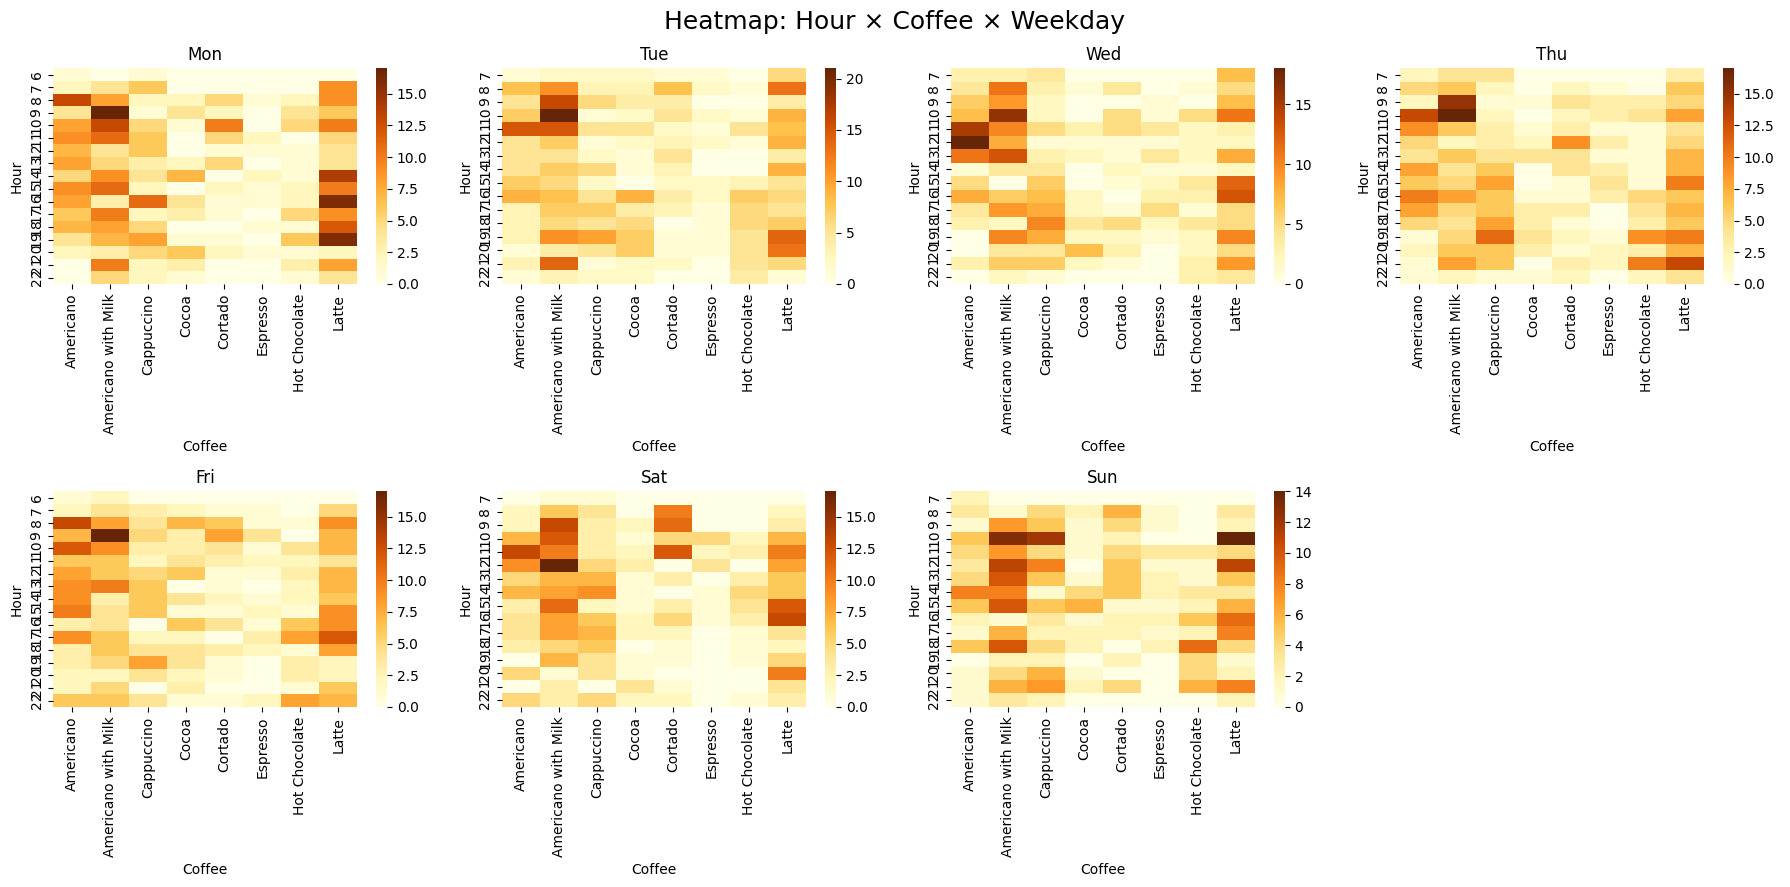

In [ ]:
# Ensure weekday ordering
order_days = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
df["Weekday"] = pd.Categorical(df["Weekday"], categories=order_days, ordered=True)

# Prepare figure with 7 subplots (one per weekday)
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, day in enumerate(order_days):
    sub = df[df["Weekday"] == day]
    pivot = pd.crosstab(sub["hour_of_day"], sub["coffee_name"])

    sns.heatmap(pivot, ax=axes[i], cmap="YlOrBr")
    axes[i].set_title(f"{day}")
    axes[i].set_xlabel("Coffee")
    axes[i].set_ylabel("Hour")

# Hide the extra subplot (8th box)
axes[-1].axis('off')

plt.suptitle("Heatmap: Hour × Coffee × Weekday", fontsize=18)
plt.tight_layout()
plt.show()

# Gráficos Avanzados
## Densidad KDE 2D (money vs hora)

Las KDE 2D son un método para visualizar la distribución de datos en un espacio bidimensional, que sirve para crear mapas de densidad y explorar relaciones entre dos variables continuas. A diferencia de los histogramas, la KDE 2D produce una representación continua y suave de la distribución, mostrando las zonas de mayor concentración de datos y facilitando la interpretación visual.

¿Qué son?
* Estimación de densidad de kernel: Es un método estadístico no paramétrico que estima la función de densidad de probabilidad (PDF) de un conjunto de datos.
* Aplicación 2D: La KDE 2D extiende este concepto para estimar la densidad de probabilidad en dos dimensiones. Cada punto de datos se representa como un pequeño "montículo" de densidad (un kernel) y la suma de todos estos montículos crea un mapa de calor o una superficie de densidad continua.
* Resultados visuales: La KDE 2D produce un gráfico que muestra la distribución de dos variables de manera conjunta, a menudo como un mapa de calor o un gráfico de contorno donde las áreas más oscuras o densas representan donde hay más puntos de datos.

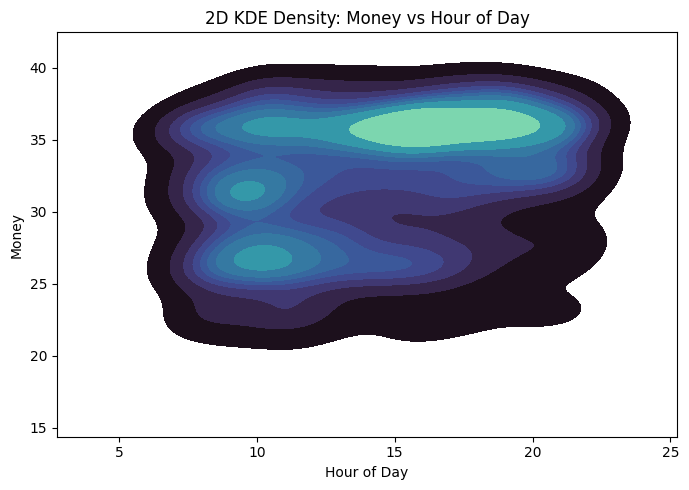

In [ ]:
# KDE 2D: money vs hour_of_day
plt.figure(figsize=(7,5))
sns.kdeplot(
    data=df,
    x="hour_of_day",
    y="money",
    fill=True,
    cmap="mako"
)
plt.title("2D KDE Density: Money vs Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Money")
plt.tight_layout()
plt.show()


### Cómo se distribuye el dinero por hora del día

* Las zonas claras/verde-azules indican mayor densidad de ventas de mayor valor.

* Las zonas oscuras indican poca concentración.

nterpretación profesional del KDE
✔ Horas con mayor densidad de ingresos

Las zonas más claras se encuentran entre:

10am – 12pm

2pm – 5pm

➡️ Estas son las horas donde se genera más dinero.

✔ Money típico por transacción

La mayor densidad está entre:

$30 y $36

con picos alrededor de $35–$37

➡️ Esto coincide con los precios de bebidas como Latte, Cappuccino y Americano with Milk.

✔ Zonas de baja densidad

Muy temprano (< 7am)

Muy tarde (> 8pm)

➡️ Menor actividad y menor ingreso.

## KDE 2D por tipo de café (uno por subplot)

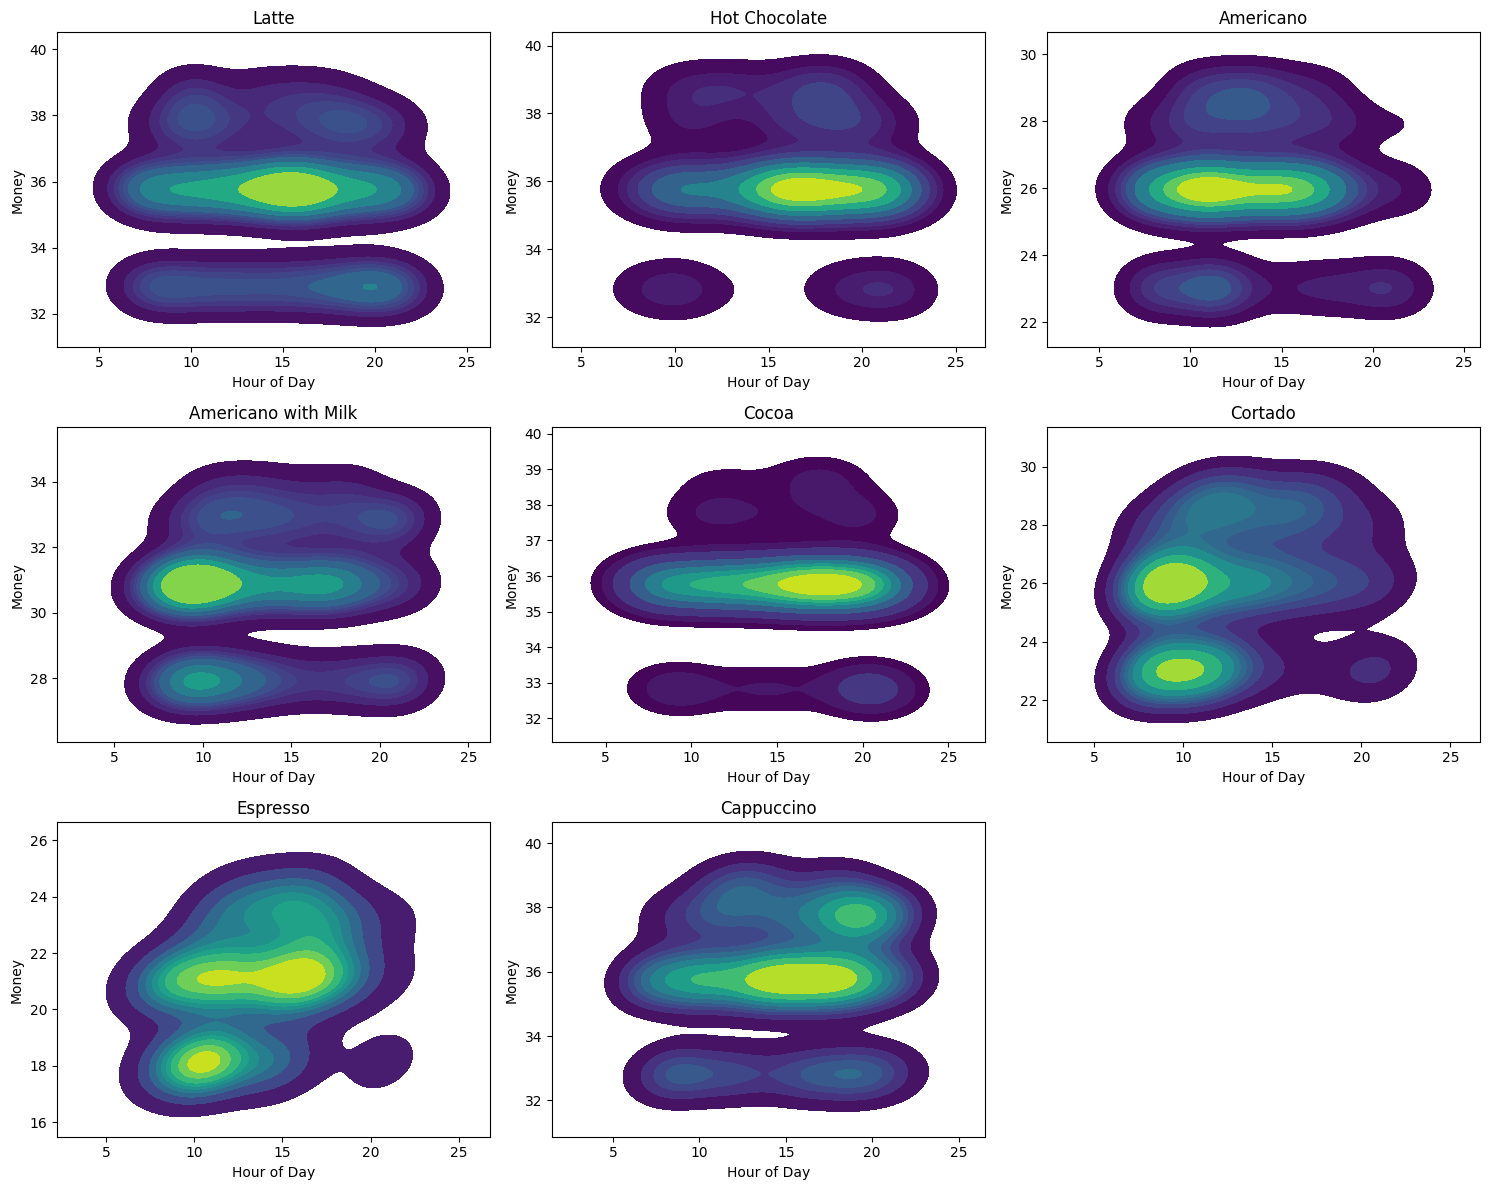

In [ ]:
# List of coffee types
coffees = df["coffee_name"].unique()

# Create subplots
num = len(coffees)
cols = 3
rows = (num // cols) + 1

plt.figure(figsize=(15, rows * 4))

for idx, coffee in enumerate(coffees, 1):
    plt.subplot(rows, cols, idx)
    sub = df[df["coffee_name"] == coffee]

    if sub.shape[0] > 5:  # Ensure enough data points
        sns.kdeplot(
            data=sub,
            x="hour_of_day",
            y="money",
            fill=True,
            cmap="viridis"
        )

    plt.title(coffee)
    plt.xlabel("Hour of Day")
    plt.ylabel("Money")

plt.tight_layout()
plt.show()


Esta visualización es altamente avanzada y muy útil para entender:

* Qué café se vende a qué hora

* Cuánto dinero mueve cada uno

* Zonas de densidad alta vs baja

* Patrones exclusivos de cada bebida

📌 Interpretación general (resumen profesional)
☕ Latte

Zonas de alta densidad entre 10am–12pm y 2pm–4pm

Ingresos típicos: $35–$37

☕ Americano

Patrón concentrado alrededor de 9am–11am

Ingresos más bajos (entre $24–$27)

☕ Americano with Milk

Una de las bebidas con mayor dispersión por horas

Ingresos típicos: $30–$33

☕ Cappuccino

Alto ingreso promedio ($36–$38)

Actividad fuerte durante casi todo el día

☕ Espresso

Zonas densas alrededor de 7am–11am

Ingresos más bajos del menú ($18–$22)

☕ Cortado

Patrón intermedio en horas y precio

☕ Cocoa / Hot Chocolate

Más ventas en tardes

Ingresos entre $33–$36

###  Individual KDE 2D por tipo de café

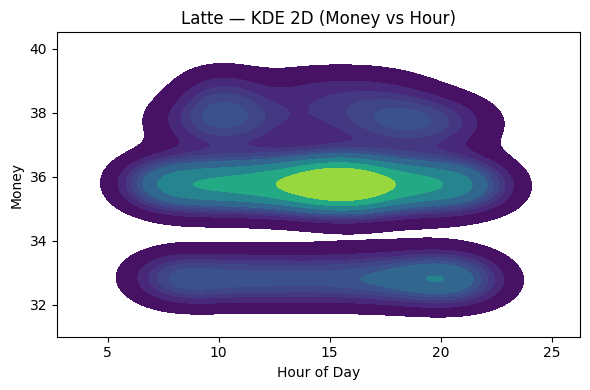

In [ ]:
sub = df[df["coffee_name"] == "Latte"]

plt.figure(figsize=(6,4))
sns.kdeplot(
    data=sub,
    x="hour_of_day",
    y="money",
    fill=True,
    cmap="viridis"
)
plt.title("Latte — KDE 2D (Money vs Hour)")
plt.xlabel("Hour of Day")
plt.ylabel("Money")
plt.tight_layout()
plt.show()


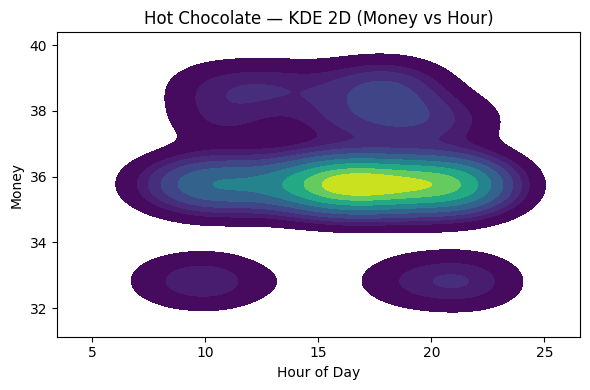

In [ ]:
sub = df[df["coffee_name"] == "Hot Chocolate"]

plt.figure(figsize=(6,4))
sns.kdeplot(
    data=sub,
    x="hour_of_day",
    y="money",
    fill=True,
    cmap="viridis"
)
plt.title("Hot Chocolate — KDE 2D (Money vs Hour)")
plt.xlabel("Hour of Day")
plt.ylabel("Money")
plt.tight_layout()
plt.show()


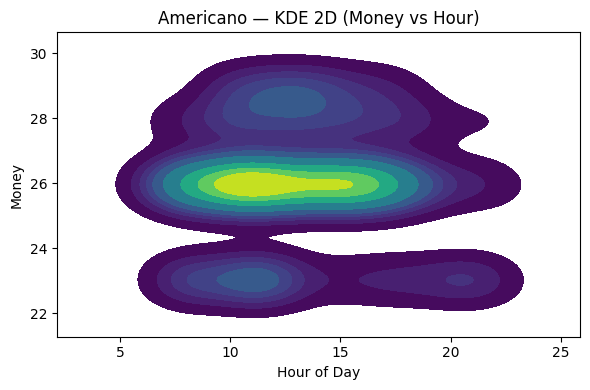

In [ ]:
sub = df[df["coffee_name"] == "Americano"]

plt.figure(figsize=(6,4))
sns.kdeplot(
    data=sub,
    x="hour_of_day",
    y="money",
    fill=True,
    cmap="viridis"
)
plt.title("Americano — KDE 2D (Money vs Hour)")
plt.xlabel("Hour of Day")
plt.ylabel("Money")
plt.tight_layout()
plt.show()


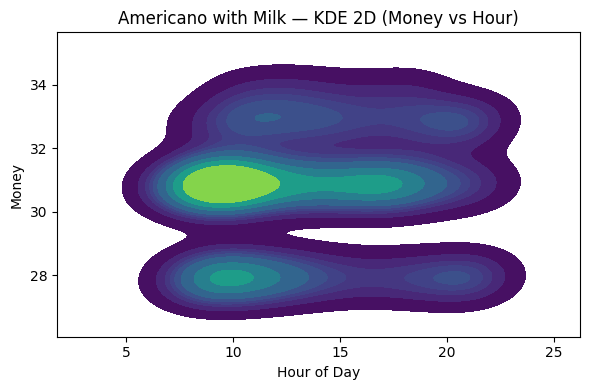

In [ ]:
sub = df[df["coffee_name"] == "Americano with Milk"]

plt.figure(figsize=(6,4))
sns.kdeplot(
    data=sub,
    x="hour_of_day",
    y="money",
    fill=True,
    cmap="viridis"
)
plt.title("Americano with Milk — KDE 2D (Money vs Hour)")
plt.xlabel("Hour of Day")
plt.ylabel("Money")
plt.tight_layout()
plt.show()


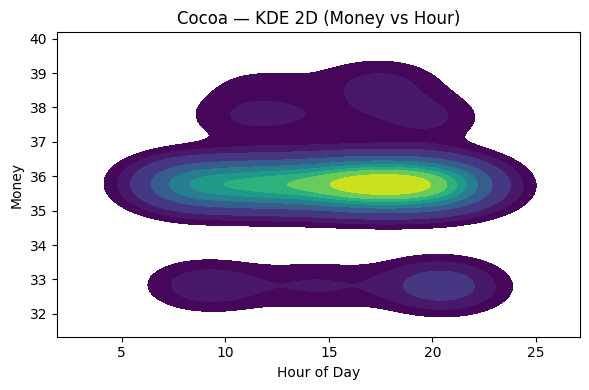

In [ ]:
sub = df[df["coffee_name"] == "Cocoa"]

plt.figure(figsize=(6,4))
sns.kdeplot(
    data=sub,
    x="hour_of_day",
    y="money",
    fill=True,
    cmap="viridis"
)
plt.title("Cocoa — KDE 2D (Money vs Hour)")
plt.xlabel("Hour of Day")
plt.ylabel("Money")
plt.tight_layout()
plt.show()


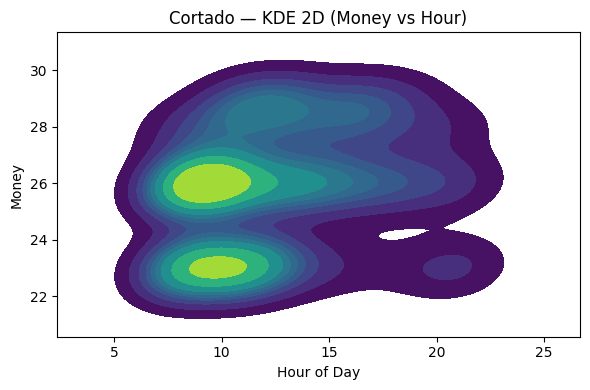

In [ ]:
sub = df[df["coffee_name"] == "Cortado"]

plt.figure(figsize=(6,4))
sns.kdeplot(
    data=sub,
    x="hour_of_day",
    y="money",
    fill=True,
    cmap="viridis"
)
plt.title("Cortado — KDE 2D (Money vs Hour)")
plt.xlabel("Hour of Day")
plt.ylabel("Money")
plt.tight_layout()
plt.show()


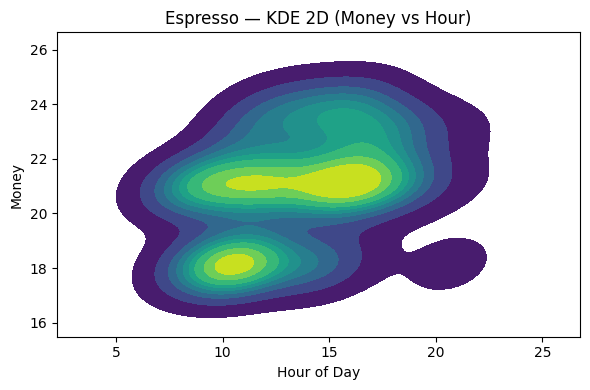

In [ ]:
sub = df[df["coffee_name"] == "Espresso"]

plt.figure(figsize=(6,4))
sns.kdeplot(
    data=sub,
    x="hour_of_day",
    y="money",
    fill=True,
    cmap="viridis"
)
plt.title("Espresso — KDE 2D (Money vs Hour)")
plt.xlabel("Hour of Day")
plt.ylabel("Money")
plt.tight_layout()
plt.show()


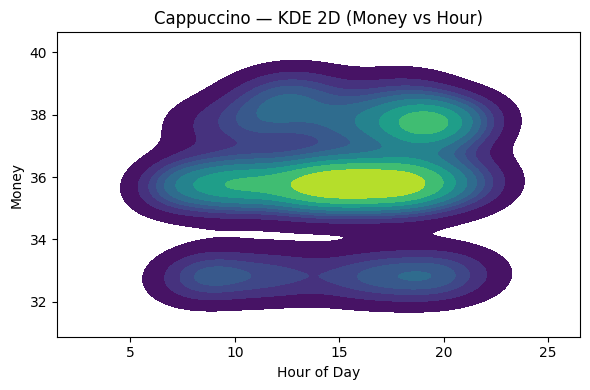

In [ ]:
sub = df[df["coffee_name"] == "Cappuccino"]

plt.figure(figsize=(6,4))
sns.kdeplot(
    data=sub,
    x="hour_of_day",
    y="money",
    fill=True,
    cmap="viridis"
)
plt.title("Cappuccino — KDE 2D (Money vs Hour)")
plt.xlabel("Hour of Day")
plt.ylabel("Money")
plt.tight_layout()
plt.show()


### Time_of_Day (Morning, Afternoon, Night) en el eje X en vez de hour_of_day.

In [ ]:
mapa = {"Morning": 1, "Afternoon": 2, "Night": 3}
df["Time_num"] = df["Time_of_Day"].map(mapa)

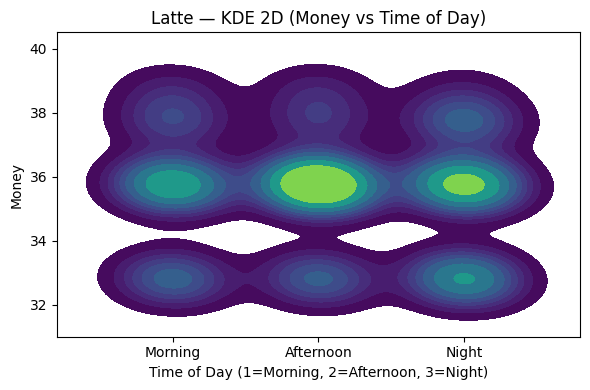

In [ ]:
# 1. Latte — KDE 2D por Time_of_Day
sub = df[df["coffee_name"] == "Latte"]

plt.figure(figsize=(6,4))
sns.kdeplot(
    data=sub,
    x="Time_num",
    y="money",
    fill=True,
    cmap="viridis"
)

plt.title("Latte — KDE 2D (Money vs Time of Day)")
plt.xlabel("Time of Day (1=Morning, 2=Afternoon, 3=Night)")
plt.ylabel("Money")
plt.xticks([1, 2, 3], ["Morning", "Afternoon", "Night"])
plt.tight_layout()
plt.show()


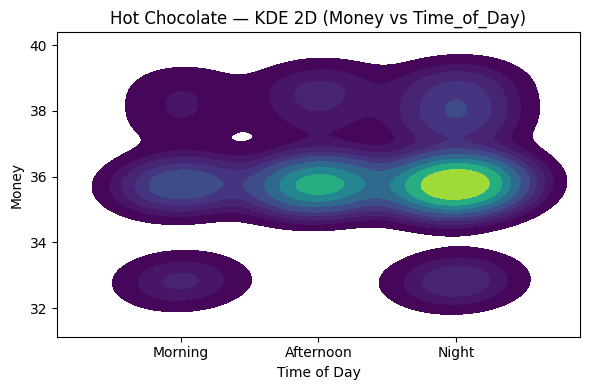

In [ ]:
#2. Hot Chocolate
sub = df[df["coffee_name"] == "Hot Chocolate"]

plt.figure(figsize=(6,4))
sns.kdeplot(
    data=sub,
    x="Time_num",
    y="money",
    fill=True,
    cmap="viridis"
)
plt.title("Hot Chocolate — KDE 2D (Money vs Time_of_Day)")
plt.xlabel("Time of Day")
plt.ylabel("Money")
plt.xticks([1, 2, 3], ["Morning", "Afternoon", "Night"])
plt.tight_layout()
plt.show()


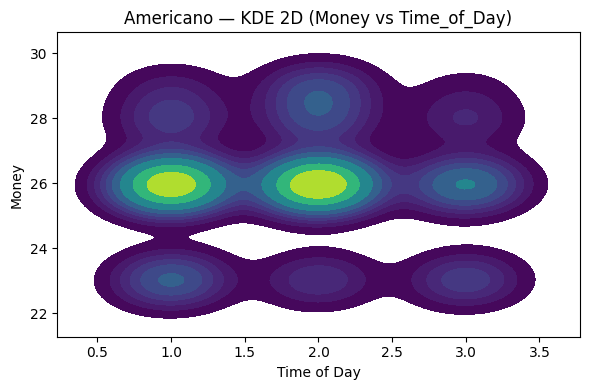

In [ ]:
# 3. Americano
sub = df[df["coffee_name"] == "Americano"]

plt.figure(figsize=(6,4))
sns.kdeplot(
    data=sub,
    x="Time_num",
    y="money",
    fill=True,
    cmap="viridis"
)
plt.title("Americano — KDE 2D (Money vs Time_of_Day)")
plt.xlabel("Time of Day")
#plt.xticks([1, 2, 3], ["Morning", "Afternoon", "Night"])
plt.ylabel("Money")
plt.tight_layout()
plt.show()


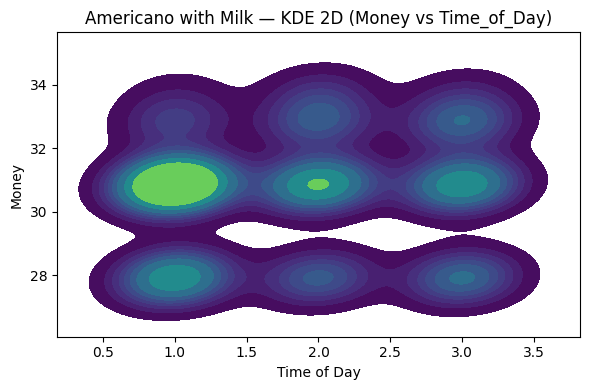

In [ ]:
# 4. Americano with Milk

sub = df[df["coffee_name"] == "Americano with Milk"]

plt.figure(figsize=(6,4))
sns.kdeplot(
    data=sub,
    x="Time_num",
    y="money",
    fill=True,
    cmap="viridis"
)
plt.title("Americano with Milk — KDE 2D (Money vs Time_of_Day)")
plt.xlabel("Time of Day")
plt.ylabel("Money")
plt.tight_layout()
plt.show()


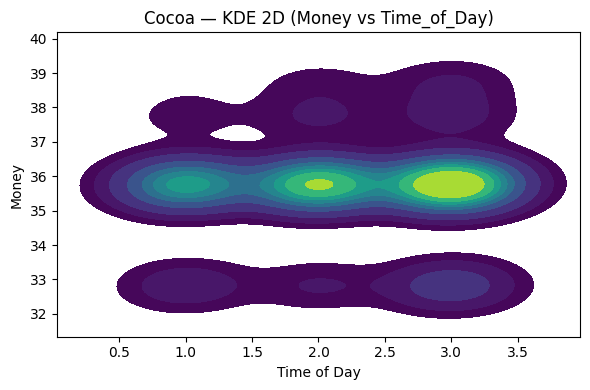

In [ ]:
# 5. Cocoa
sub = df[df["coffee_name"] == "Cocoa"]

plt.figure(figsize=(6,4))
sns.kdeplot(
    data=sub,
    x="Time_num",
    y="money",
    fill=True,
    cmap="viridis"
)
plt.title("Cocoa — KDE 2D (Money vs Time_of_Day)")
plt.xlabel("Time of Day")
plt.ylabel("Money")
plt.tight_layout()
plt.show()


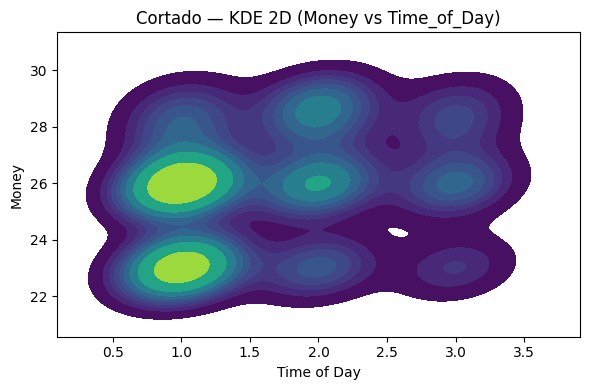

In [ ]:
# 6. Cortado
sub = df[df["coffee_name"] == "Cortado"]

plt.figure(figsize=(6,4))
sns.kdeplot(
    data=sub,
    x="Time_num",
    y="money",
    fill=True,
    cmap="viridis"
)
plt.title("Cortado — KDE 2D (Money vs Time_of_Day)")
plt.xlabel("Time of Day")
plt.ylabel("Money")
plt.tight_layout()
plt.show()


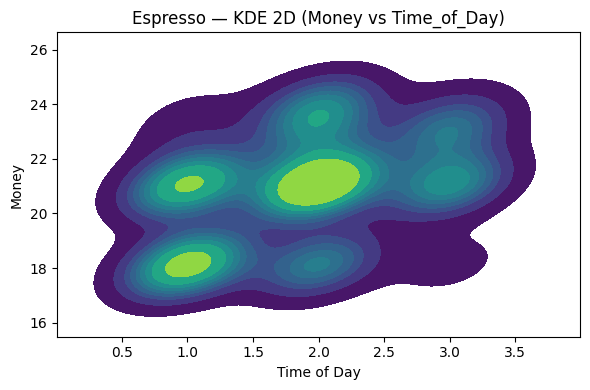

In [ ]:
# 7. Espresso
sub = df[df["coffee_name"] == "Espresso"]

plt.figure(figsize=(6,4))
sns.kdeplot(
    data=sub,
    x="Time_num",
    y="money",
    fill=True,
    cmap="viridis"
)
plt.title("Espresso — KDE 2D (Money vs Time_of_Day)")
plt.xlabel("Time of Day")
plt.ylabel("Money")
plt.tight_layout()
plt.show()


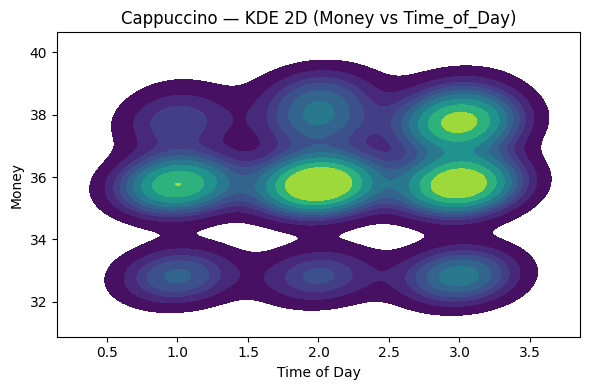

In [ ]:
# 8. Cappuccino
sub = df[df["coffee_name"] == "Cappuccino"]

plt.figure(figsize=(6,4))
sns.kdeplot(
    data=sub,
    x="Time_num",
    y="money",
    fill=True,
    cmap="viridis"
)
plt.title("Cappuccino — KDE 2D (Money vs Time_of_Day)")
plt.xlabel("Time of Day")
plt.ylabel("Money")
plt.tight_layout()
plt.show()


### Comparación KDE 2D: dos cafés en un solo gráfico

/tmp/ipython-input-1596040583.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


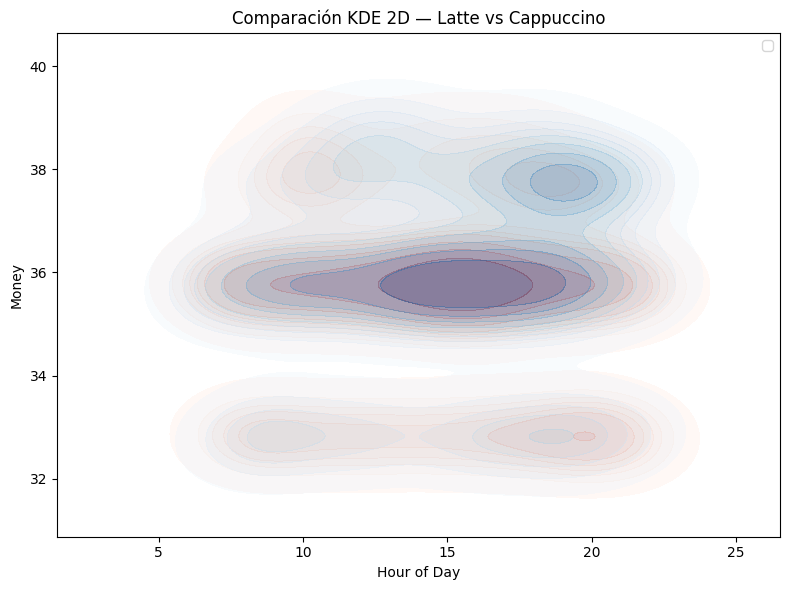

In [ ]:
# Escoger las dos bebidas
coffee1 = "Latte"
coffee2 = "Cappuccino"

sub1 = df[df["coffee_name"] == coffee1]
sub2 = df[df["coffee_name"] == coffee2]

plt.figure(figsize=(8,6))

# KDE 2D para bebida 1
sns.kdeplot(
    data=sub1,
    x="hour_of_day",
    y="money",
    fill=True,
    alpha=0.4,
    cmap="Reds",
    label=coffee1
)

# KDE 2D para bebida 2
sns.kdeplot(
    data=sub2,
    x="hour_of_day",
    y="money",
    fill=True,
    alpha=0.4,
    cmap="Blues",
    label=coffee2
)

plt.title(f"Comparación KDE 2D — {coffee1} vs {coffee2}")
plt.xlabel("Hour of Day")
plt.ylabel("Money")
plt.legend()
plt.tight_layout()
plt.show()


✔ ¿Qué te muestra este gráfico?

* Zonas rojas = mayor densidad de Latte

* Zonas azules = mayor densidad de Cappuccino

* Zonas púrpuras = donde coinciden ambas

* Comparas horas, precios y patrones de compra a la vez

Súper útil para:

* Competencia entre productos

* Análisis de sustitución

* Horas con predominio de un café

* Visualización clara con dos distribuciones sobrepuestas

/tmp/ipython-input-2991328889.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


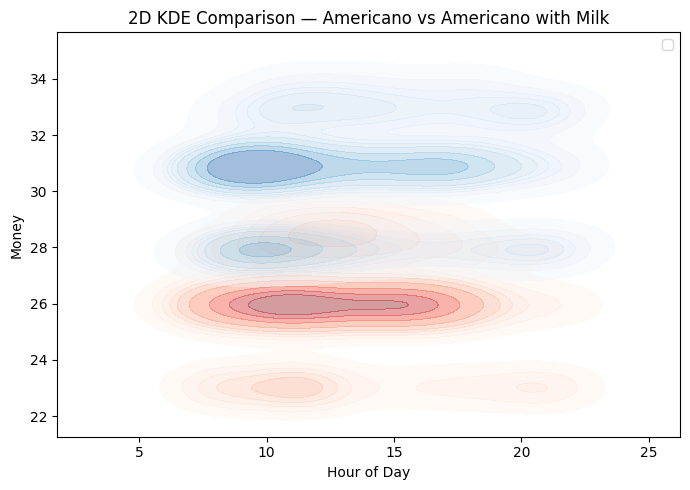

In [ ]:
# Americano vs Americano with Milk
sub1 = df[df["coffee_name"] == "Americano"]
sub2 = df[df["coffee_name"] == "Americano with Milk"]

plt.figure(figsize=(7,5))

sns.kdeplot(
    data=sub1,
    x="hour_of_day",
    y="money",
    fill=True,
    cmap="Reds",
    alpha=0.4,
    label="Americano"
)

sns.kdeplot(
    data=sub2,
    x="hour_of_day",
    y="money",
    fill=True,
    cmap="Blues",
    alpha=0.4,
    label="Americano with Milk"
)

plt.title("2D KDE Comparison — Americano vs Americano with Milk")
plt.xlabel("Hour of Day")
plt.ylabel("Money")
plt.legend()
plt.tight_layout()
plt.show()


/tmp/ipython-input-1580295114.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


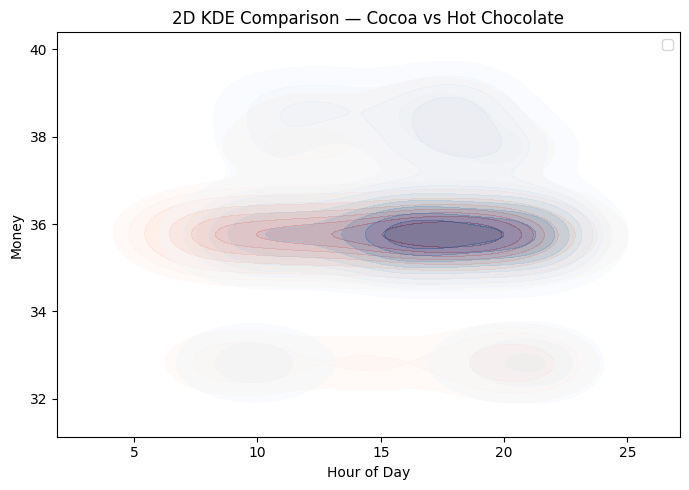

In [ ]:
# Cocoa vs Hot Chocolate
sub1 = df[df["coffee_name"] == "Cocoa"]
sub2 = df[df["coffee_name"] == "Hot Chocolate"]

plt.figure(figsize=(7,5))

sns.kdeplot(
    data=sub1,
    x="hour_of_day",
    y="money",
    fill=True,
    cmap="Reds",
    alpha=0.4,
    label="Cocoa"
)

sns.kdeplot(
    data=sub2,
    x="hour_of_day",
    y="money",
    fill=True,
    cmap="Blues",
    alpha=0.4,
    label="Hot Chocolate"
)

plt.title("2D KDE Comparison — Cocoa vs Hot Chocolate")
plt.xlabel("Hour of Day")
plt.ylabel("Money")
plt.legend()
plt.tight_layout()
plt.show()


/tmp/ipython-input-3806091864.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


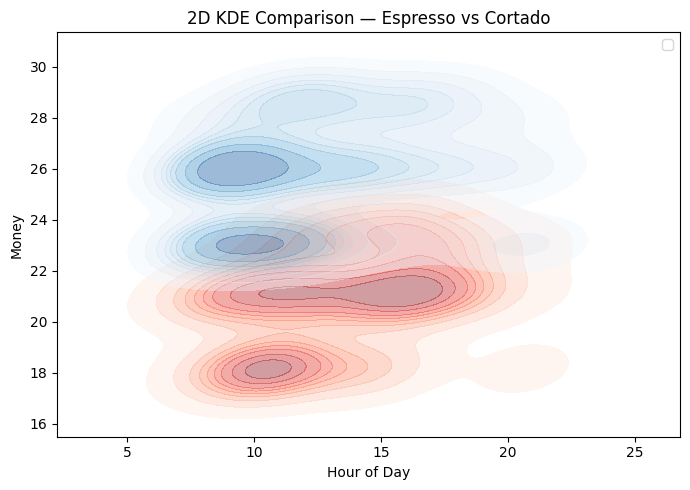

In [ ]:
# Espresso vs Cortado
sub1 = df[df["coffee_name"] == "Espresso"]
sub2 = df[df["coffee_name"] == "Cortado"]

plt.figure(figsize=(7,5))

sns.kdeplot(
    data=sub1,
    x="hour_of_day",
    y="money",
    fill=True,
    cmap="Reds",
    alpha=0.4,
    label="Espresso"
)

sns.kdeplot(
    data=sub2,
    x="hour_of_day",
    y="money",
    fill=True,
    cmap="Blues",
    alpha=0.4,
    label="Cortado"
)

plt.title("2D KDE Comparison — Espresso vs Cortado")
plt.xlabel("Hour of Day")
plt.ylabel("Money")
plt.legend()
plt.tight_layout()
plt.show()


### comparación pero usando Time_of_Day (Morning/Afternoon/Night)

In [ ]:
# Mapear Time_of_Day a valores numéricos
mapa = {"Morning": 1, "Afternoon": 2, "Night": 3}
df["Time_num"] = df["Time_of_Day"].map(mapa)


/tmp/ipython-input-4123080462.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


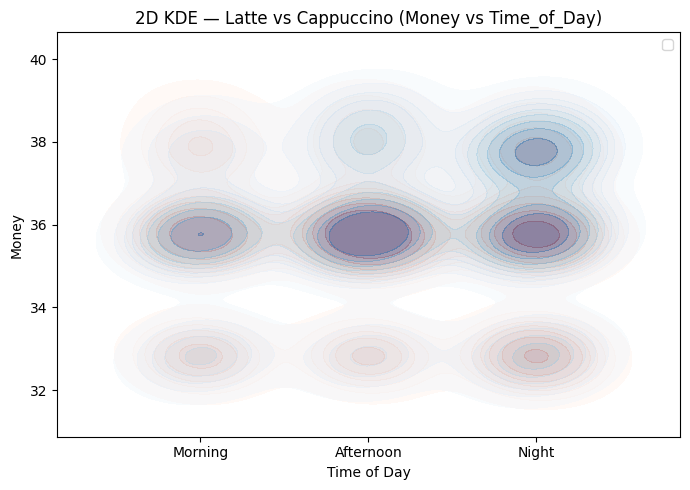

In [ ]:
# Latte vs Cappuccino
sub1 = df[df["coffee_name"] == "Latte"]
sub2 = df[df["coffee_name"] == "Cappuccino"]

plt.figure(figsize=(7,5))

sns.kdeplot(
    data=sub1,
    x="Time_num",
    y="money",
    fill=True,
    cmap="Reds",
    alpha=0.4,
    label="Latte"
)

sns.kdeplot(
    data=sub2,
    x="Time_num",
    y="money",
    fill=True,
    cmap="Blues",
    alpha=0.4,
    label="Cappuccino"
)

plt.title("2D KDE — Latte vs Cappuccino (Money vs Time_of_Day)")
plt.xlabel("Time of Day")
plt.ylabel("Money")
plt.xticks([1, 2, 3], ["Morning", "Afternoon", "Night"])
plt.legend()
plt.tight_layout()
plt.show()


/tmp/ipython-input-4159672757.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


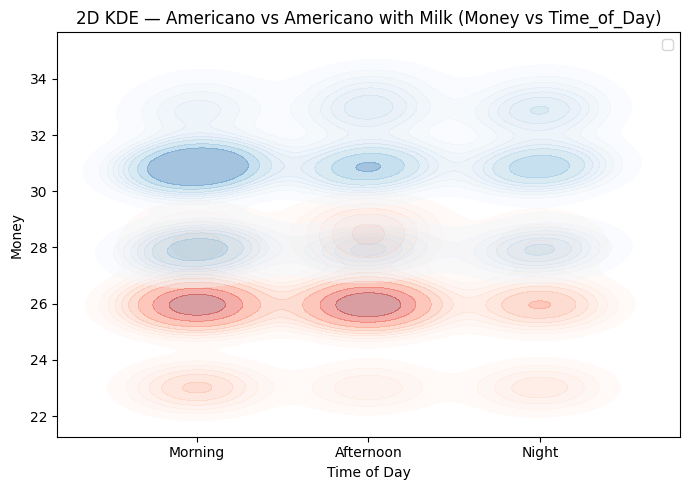

In [ ]:
# Americano vs Americano with Milk
sub1 = df[df["coffee_name"] == "Americano"]
sub2 = df[df["coffee_name"] == "Americano with Milk"]

plt.figure(figsize=(7,5))

sns.kdeplot(
    data=sub1,
    x="Time_num",
    y="money",
    fill=True,
    cmap="Reds",
    alpha=0.4,
    label="Americano"
)

sns.kdeplot(
    data=sub2,
    x="Time_num",
    y="money",
    fill=True,
    cmap="Blues",
    alpha=0.4,
    label="Americano with Milk"
)

plt.title("2D KDE — Americano vs Americano with Milk (Money vs Time_of_Day)")
plt.xlabel("Time of Day")
plt.ylabel("Money")
plt.xticks([1, 2, 3], ["Morning", "Afternoon", "Night"])
plt.legend()
plt.tight_layout()
plt.show()


/tmp/ipython-input-3287428576.py:31: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


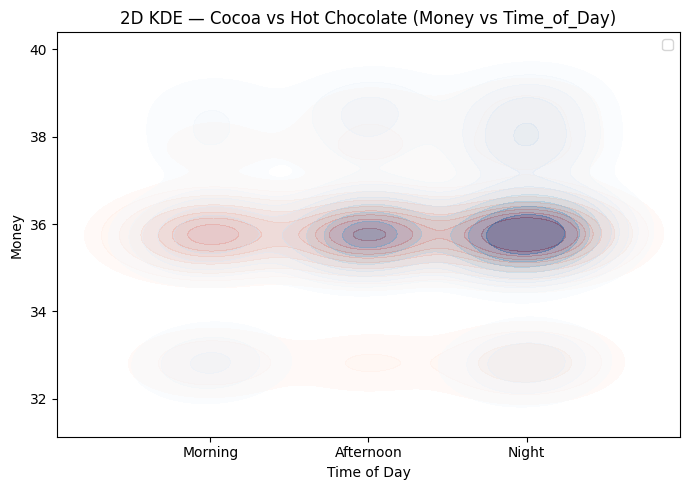

In [ ]:
# Cocoa vs Hot Chocolate
sub1 = df[df["coffee_name"] == "Cocoa"]
sub2 = df[df["coffee_name"] == "Hot Chocolate"]

plt.figure(figsize=(7,5))

sns.kdeplot(
    data=sub1,
    x="Time_num",
    y="money",
    fill=True,
    cmap="Reds",
    alpha=0.4,
    label="Cocoa"
)

sns.kdeplot(
    data=sub2,
    x="Time_num",
    y="money",
    fill=True,
    cmap="Blues",
    alpha=0.4,
    label="Hot Chocolate"
)

plt.title("2D KDE — Cocoa vs Hot Chocolate (Money vs Time_of_Day)")
plt.xlabel("Time of Day")
plt.ylabel("Money")
plt.xticks([1, 2, 3], ["Morning", "Afternoon", "Night"])
plt.legend()
plt.tight_layout()
plt.show()


/tmp/ipython-input-1385028394.py:31: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


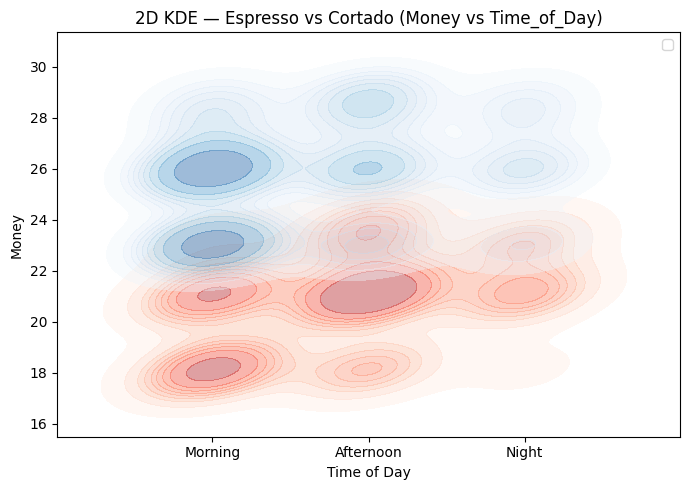

In [ ]:
# Espresso vs Cortado
sub1 = df[df["coffee_name"] == "Espresso"]
sub2 = df[df["coffee_name"] == "Cortado"]

plt.figure(figsize=(7,5))

sns.kdeplot(
    data=sub1,
    x="Time_num",
    y="money",
    fill=True,
    cmap="Reds",
    alpha=0.4,
    label="Espresso"
)

sns.kdeplot(
    data=sub2,
    x="Time_num",
    y="money",
    fill=True,
    cmap="Blues",
    alpha=0.4,
    label="Cortado"
)

plt.title("2D KDE — Espresso vs Cortado (Money vs Time_of_Day)")
plt.xlabel("Time of Day")
plt.ylabel("Money")
plt.xticks([1, 2, 3], ["Morning", "Afternoon", "Night"])
plt.legend()
plt.tight_layout()
plt.show()


## Gráficos Avanzados de Distribución

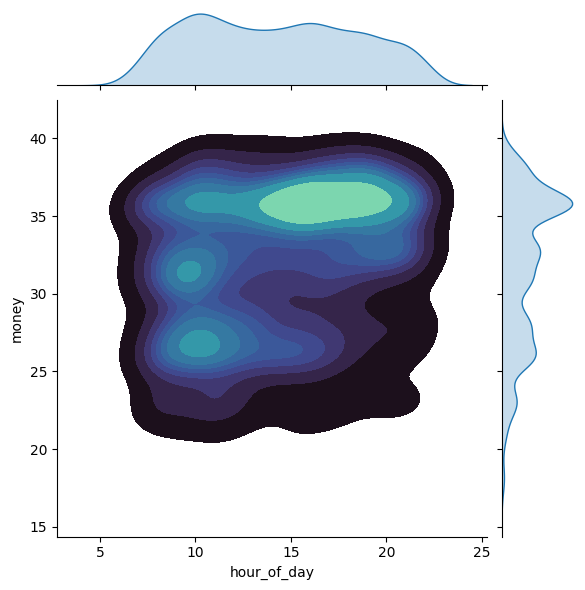

In [ ]:
# --- 1) JOINTPLOT KDE (money vs hour_of_day) ---
sns.jointplot(
    data=df,
    x="hour_of_day",
    y="money",
    kind="kde",
    fill=True,
    cmap="mako"
)



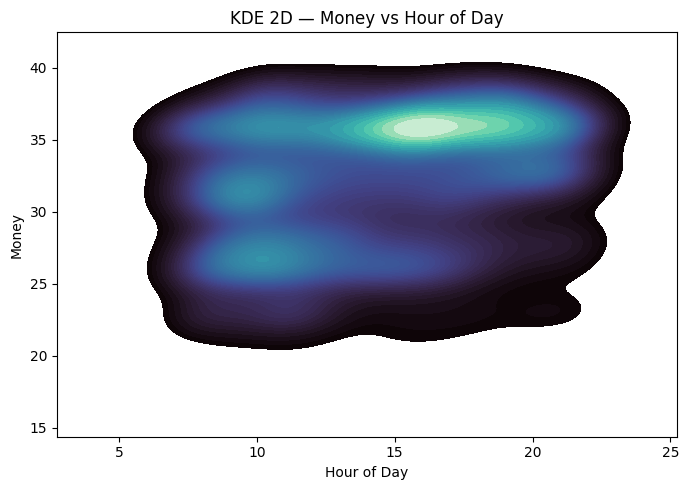

In [ ]:
df["hour_of_day"] = pd.to_numeric(df["hour_of_day"], errors="coerce")
df["money"] = pd.to_numeric(df["money"], errors="coerce")

plt.figure(figsize=(7,5))
sns.kdeplot(
    data=df,
    x="hour_of_day",
    y="money",
    cmap="mako",
    fill=True,
    levels=50
)
plt.title("KDE 2D — Money vs Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Money")
plt.tight_layout()
plt.show()


Un "rugplot" es un gráfico que muestra la distribución de una variable cuantitativa mediante pequeñas marcas o "alfombras" a lo largo de un solo eje. Cada marca representa un punto de dato individual, por lo que es útil para visualizar la densidad y la ubicación de los valores en una distribución. A menudo se usa junto con otros gráficos, como diagramas de dispersión o histogramas, para complementar la información y mostrar las distribuciones marginales de los datos.

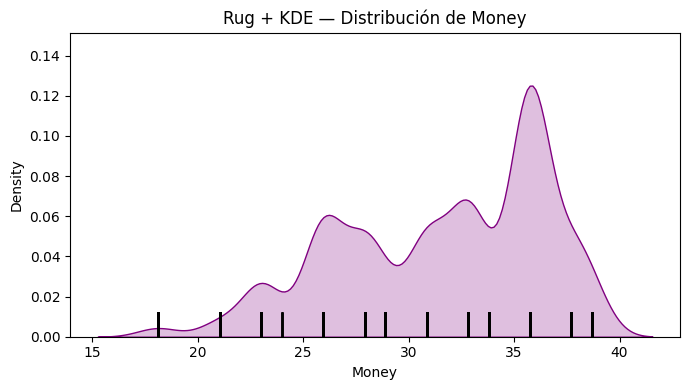

In [ ]:
plt.figure(figsize=(7,4))
sns.kdeplot(data=df, x="money", fill=True, color="purple")
sns.rugplot(data=df, x="money", height=0.08, color="black")
plt.title("Rug + KDE — Distribución de Money")
plt.xlabel("Money")
plt.tight_layout()
plt.show()


/tmp/ipython-input-3300702031.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


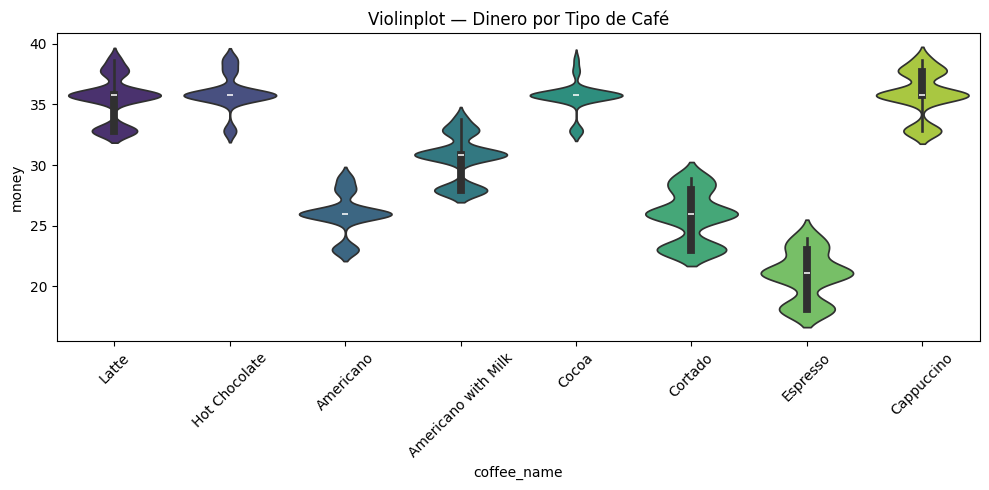

In [ ]:
plt.figure(figsize=(10,5))
sns.violinplot(
    data=df,
    x="coffee_name",
    y="money",
    palette="viridis"
)
plt.xticks(rotation=45)
plt.title("Violinplot — Dinero por Tipo de Café")
plt.tight_layout()
plt.show()


### Gráficos Avanzados de Correlaciones y Relaciones

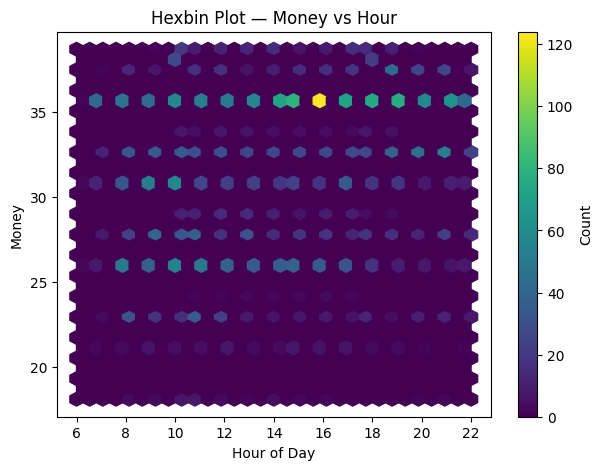

In [ ]:
# HEXBIN PLOT — Densidad por celdas hexagonales
plt.figure(figsize=(7,5))
plt.hexbin(df["hour_of_day"], df["money"], gridsize=30, cmap="viridis")
plt.colorbar(label="Count")
plt.xlabel("Hour of Day")
plt.ylabel("Money")
plt.title("Hexbin Plot — Money vs Hour")
plt.show()


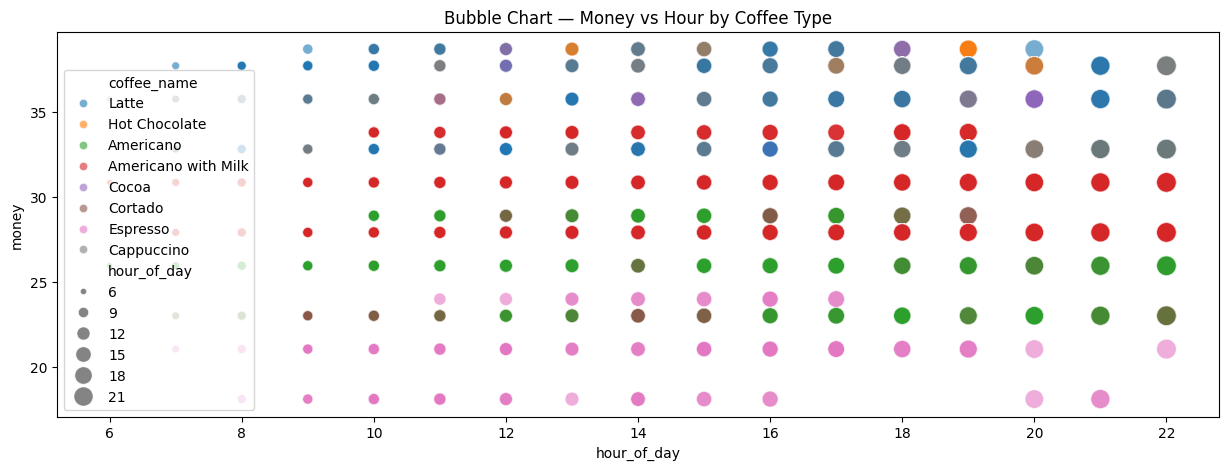

In [ ]:
#SCATTERPLOT + BUBBLES (3 variables a la vez)
plt.figure(figsize=(15,5))
sns.scatterplot(
    data=df,
    x="hour_of_day",
    y="money",
    hue="coffee_name",
    size="hour_of_day",
    sizes=(20, 200),
    alpha=0.6
)

plt.title("Bubble Chart — Money vs Hour by Coffee Type")
plt.show()


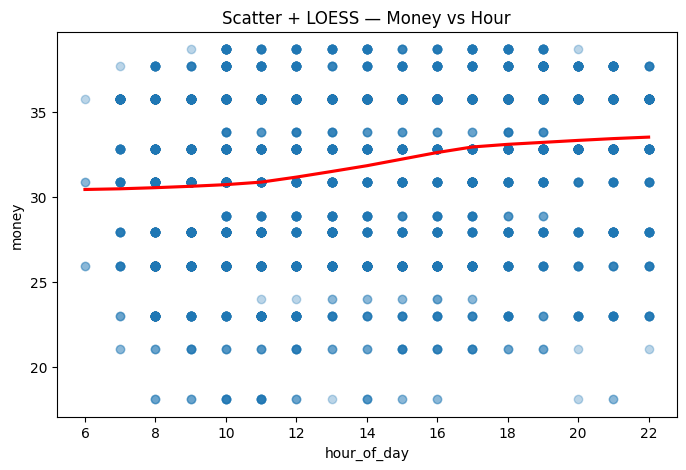

In [ ]:
# SCATTERPLOT con suavización LOESS
plt.figure(figsize=(8,5))
sns.regplot(
    data=df,
    x="hour_of_day",
    y="money",
    lowess=True,
    scatter_kws={"alpha":0.3},
    line_kws={"color":"red"}
)
plt.title("Scatter + LOESS — Money vs Hour")
plt.show()


# Gráficos Avanzados de Outliers y Variabilidad

/tmp/ipython-input-859645677.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(data=df, x="coffee_name", y="money", palette="viridis")


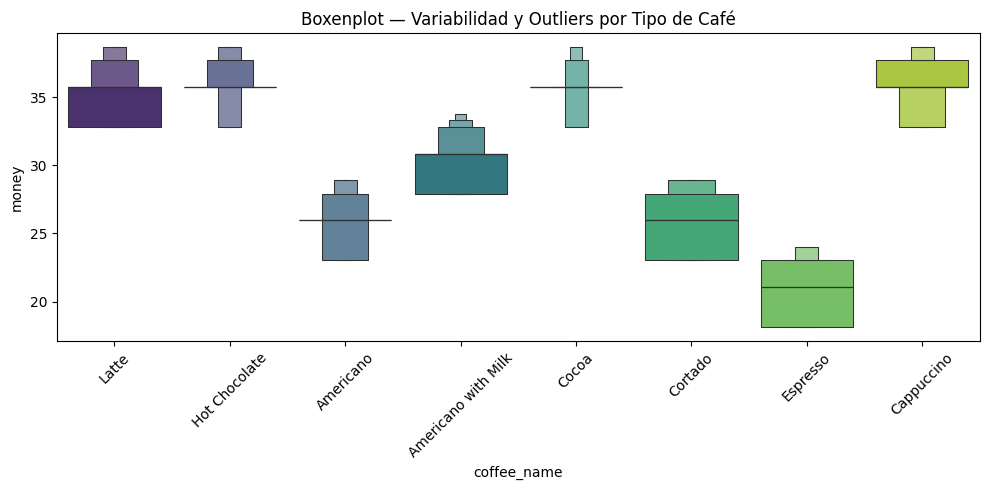

In [ ]:
plt.figure(figsize=(10,5))
sns.boxenplot(data=df, x="coffee_name", y="money", palette="viridis")
plt.xticks(rotation=45)
plt.title("Boxenplot — Variabilidad y Outliers por Tipo de Café")
plt.tight_layout()
plt.show()


* Muestra colas largas
* Detecta outliers con más precisión que boxplot
* Ideal para distribuciones no normales

/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 93.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 81.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 90.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 93.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 79.9% of the points cannot be plac

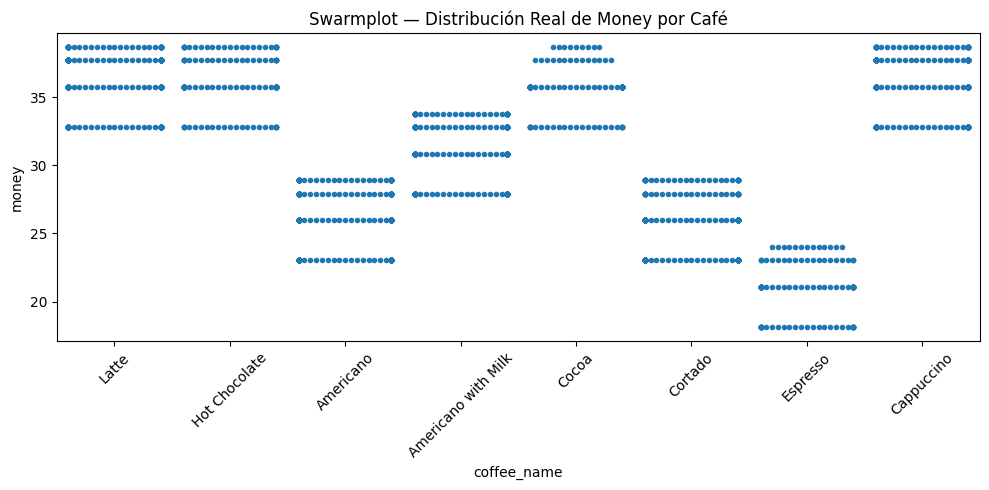

In [ ]:
plt.figure(figsize=(10,5))
sns.swarmplot(data=df, x="coffee_name", y="money", size=4)
plt.xticks(rotation=45)
plt.title("Swarmplot — Distribución Real de Money por Café")
plt.tight_layout()
plt.show()


* 100% basado en datos reales
* Muestra densidad a simple vista
* Excelente para detectar patrones y outliers exactos

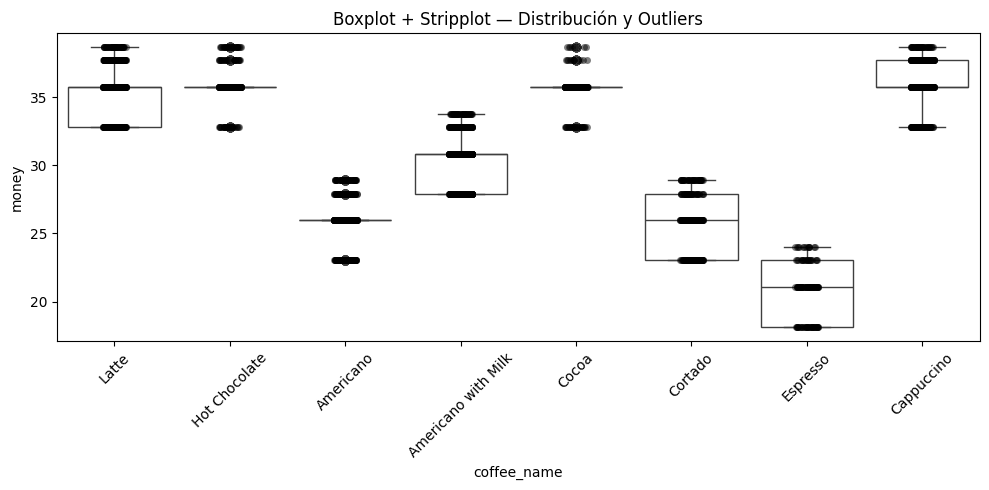

In [ ]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x="coffee_name", y="money", showcaps=True, boxprops={"facecolor":"none"})
sns.stripplot(data=df, x="coffee_name", y="money", color="black", alpha=0.5)
plt.xticks(rotation=45)
plt.title("Boxplot + Stripplot — Distribución y Outliers")
plt.tight_layout()
plt.show()


/tmp/ipython-input-484783425.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


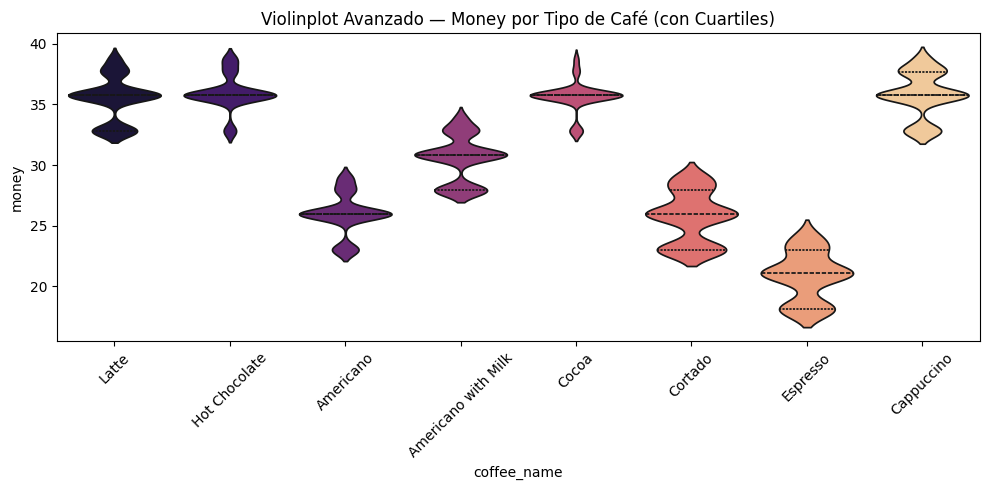

In [ ]:
plt.figure(figsize=(10,5))
sns.violinplot(
    data=df,
    x="coffee_name",
    y="money",
    inner="quartile",
    palette="magma"
)
plt.xticks(rotation=45)
plt.title("Violinplot Avanzado — Money por Tipo de Café (con Cuartiles)")
plt.tight_layout()
plt.show()


### Gráficos Avanzados Multivariados

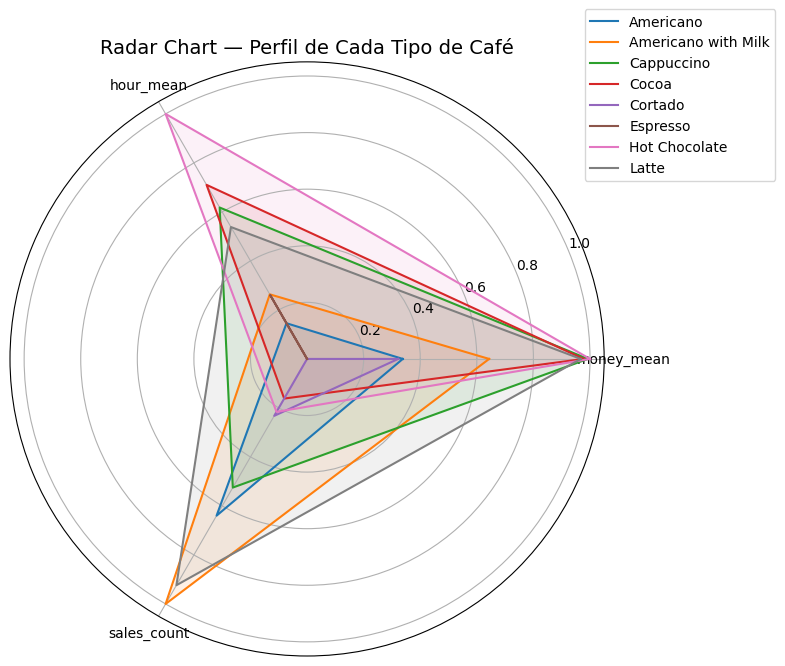

In [ ]:
#Radar Chart (perfil de cada café)
# Clean money column
df["money"] = df["money"].astype(str).str.replace("$", "", regex=False).str.strip()
df["money"] = pd.to_numeric(df["money"], errors="coerce")
df["hour_of_day"] = pd.to_numeric(df["hour_of_day"], errors="coerce")

# Compute metrics per coffee
metrics = df.groupby("coffee_name").agg(
    money_mean=("money", "mean"),
    hour_mean=("hour_of_day", "mean"),
    sales_count=("money", "count")
)

# Normalize values between 0 and 1
norm_metrics = (metrics - metrics.min()) / (metrics.max() - metrics.min())
norm_metrics = norm_metrics.fillna(0)

# Radar chart setup
labels = norm_metrics.columns.tolist()
num_vars = len(labels)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

plt.figure(figsize=(8,8))

for coffee in norm_metrics.index:
    values = norm_metrics.loc[coffee].tolist()
    values += values[:1]
    plt.polar(angles, values, label=coffee)
    plt.fill(angles, values, alpha=0.1)

plt.xticks(angles[:-1], labels)
plt.title("Radar Chart — Perfil de Cada Tipo de Café", size=14)
plt.legend(bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()


Aquí tienes un gráfico multivariado profesional, donde cada café se representa mediante un “perfil” en 3 dimensiones:

* money_mean — precio promedio
* hour_mean — hora promedio de compra
* sales_count — número total de transacciones

Todo fue normalizado, así se pueden comparar variables muy distintas en una misma escala.

Cómo interpretar el Radar Chart
1. Cafés que sobresalen en precio (money_mean alto)

* Hot Chocolate

* Latte

* Cappuccino

Estos aparecen “estirados” hacia el eje money_mean.

2. Cafés con mayor frecuencia de ventas (sales_count)

* Americano with Milk

* Latte

Se nota en el eje sales_count donde sus líneas llegan más lejos.

3. Cafés con horas más tardías (hour_mean más alto)

* Hot Chocolate

* Cocoa

Indica que suelen venderse más en horas posteriores.

Conclusiones inmediatas

* Latte tiene un perfil muy equilibrado: alto precio, hora media, muchas ventas.

* Americano with Milk es el más vendido, aunque no el más costoso.

* Hot Chocolate es costoso y se compra más tarde.

* Espresso es más temprano, más barato y con menos ventas.

### Los 8 Radar Charts individuales se generaron correctamente, uno por cada tipo de café

Cada radar muestra el perfil normalizado de:

* money_mean → precio promedio

* hour_mean → hora promedio de compra

* sales_count → número total de ventas

* money_std → variabilidad del precio

In [ ]:
# Limpiar columnas numéricas
df["money"] = df["money"].astype(str).str.replace("$","", regex=False).str.strip()
df["money"] = pd.to_numeric(df["money"], errors="coerce")
df["hour_of_day"] = pd.to_numeric(df["hour_of_day"], errors="coerce")

# Construir métricas necesarias
metrics = df.groupby("coffee_name").agg(
    money_mean=("money","mean"),
    hour_mean=("hour_of_day","mean"),
    sales_count=("money","count"),
    money_std=("money","std")
)

# Normalizar
norm = (metrics - metrics.min()) / (metrics.max() - metrics.min())
norm = norm.fillna(0)

labels = norm.columns.tolist()
num_vars = len(labels)
angles = np.linspace(0, 2*np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]


##  ¿Qué es un Radar Chart?

Es un gráfico donde:

* Cada eje representa una variable.

* Cada círculo concéntrico representa un nivel de escala entre 0 y 1.

* La línea azul muestra el perfil del café Americano comparado con los demás cafés.

* Como todo está normalizado entre 0 y 1, puedes comparar variables diferentes en la misma escala.

## ¿Qué significa cada círculo?

Los círculos concéntricos representan niveles de magnitud:

* Centro (0.0) → Valor mínimo de todos los cafés

* Primer círculo (0.1 – 0.2) → Valor bajo

* Segundo círculo (0.3 – 0.4) → Valor medio

* Tercer círculo (0.5 – 0.6) → Valor alto

* Borde externo (1.0) → Valor máximo entre todos los cafés

No son cantidades reales, sino valores normalizados para comparar perfiles.

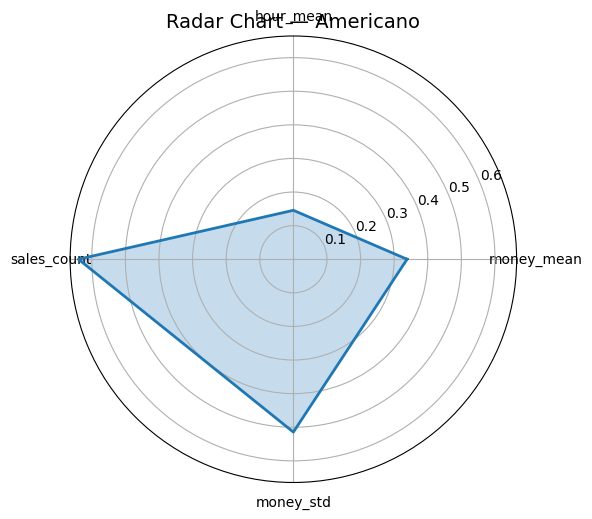

In [ ]:
# 1. Radar Chart — Americano
values = norm.loc["Americano"].tolist()
values += values[:1]

plt.figure(figsize=(6,6))
plt.polar(angles, values, linewidth=2)
plt.fill(angles, values, alpha=0.25)
plt.xticks(angles[:-1], labels)
plt.title("Radar Chart — Americano", size=14)
plt.tight_layout()
plt.show()


¿Qué representa cada variable?

En tu radar aparecen cuatro variables:

1. money_mean

Precio promedio del Americano comparado con otros cafés.
El valor cae en 0.32 aprox → es un precio medio-bajo.

2. hour_mean

Hora promedio en la que se vende.
Cae en 0.15 aprox → significa que el Americano se vende más temprano comparado con otros cafés.

3. sales_count

Cantidad total de ventas (popularidad).
Cae en 0.65 aprox → Americano es uno de los más vendidos del menú.

4. money_std

Desviación estándar del precio (variabilidad).
Cae cerca de 0.50 → variabilidad media del precio (hay café con variabilidad mayor y menor).

1️⃣ Muy popular (sales_count es el valor más alto del gráfico).
2️⃣ Precio medio-bajo, no es un café costoso.
3️⃣ Se consume tempranito (hour_mean bajo).
4️⃣ Variabilidad moderada del precio (money_std en la mitad).

✔ Conclusión profesional:

El Americano es un café de precio accesible, consumo temprano y alto volumen de ventas, lo que lo convierte en una de las bebidas más populares y estables del menú.

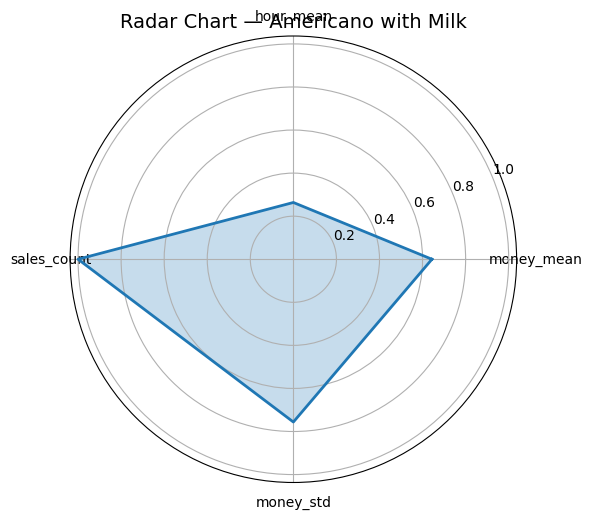

In [ ]:
# 2. Radar Chart — Americano with Milk
values = norm.loc["Americano with Milk"].tolist()
values += values[:1]

plt.figure(figsize=(6,6))
plt.polar(angles, values, linewidth=2)
plt.fill(angles, values, alpha=0.25)
plt.xticks(angles[:-1], labels)
plt.title("Radar Chart — Americano with Milk", size=14)
plt.tight_layout()
plt.show()


Americano with Milk

* Precio medio más alto que Americano

* Variabilidad moderada

* El más vendido de todos

* Hora promedio temprana

El café más dominante en ventas.

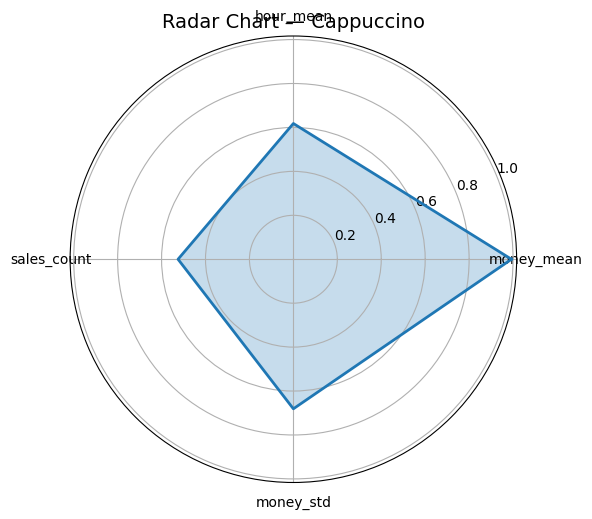

In [ ]:
# 3. Radar Chart — Cappuccino
values = norm.loc["Cappuccino"].tolist()
values += values[:1]

plt.figure(figsize=(6,6))
plt.polar(angles, values, linewidth=2)
plt.fill(angles, values, alpha=0.25)
plt.xticks(angles[:-1], labels)
plt.title("Radar Chart — Cappuccino", size=14)
plt.tight_layout()
plt.show()


3. Cappuccino

* Precio medio alto

* Variabilidad moderada

* Cantidad de ventas media

* Hora más tardía del día

Popular en horarios más avanzados.*

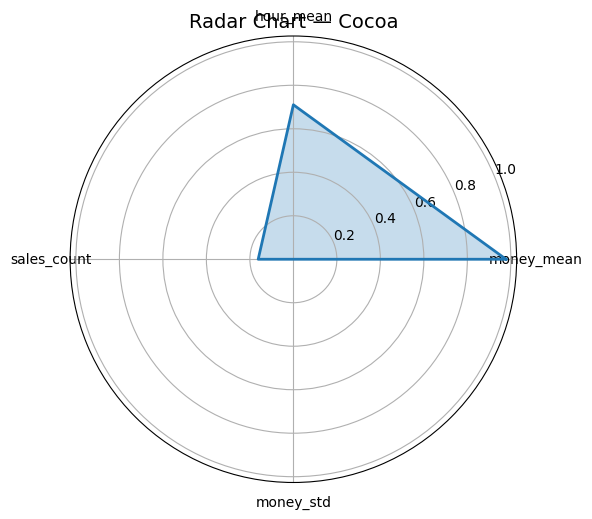

In [ ]:
# 4. Radar Chart — Cocoa
values = norm.loc["Cocoa"].tolist()
values += values[:1]

plt.figure(figsize=(6,6))
plt.polar(angles, values, linewidth=2)
plt.fill(angles, values, alpha=0.25)
plt.xticks(angles[:-1], labels)
plt.title("Radar Chart — Cocoa", size=14)
plt.tight_layout()
plt.show()


4. Cocoa

* Precio más alto del menú

* Hora tardía

* Pocas ventas

* Variabilidad casi nula

Producto premium, nicho, con consumo tarde.

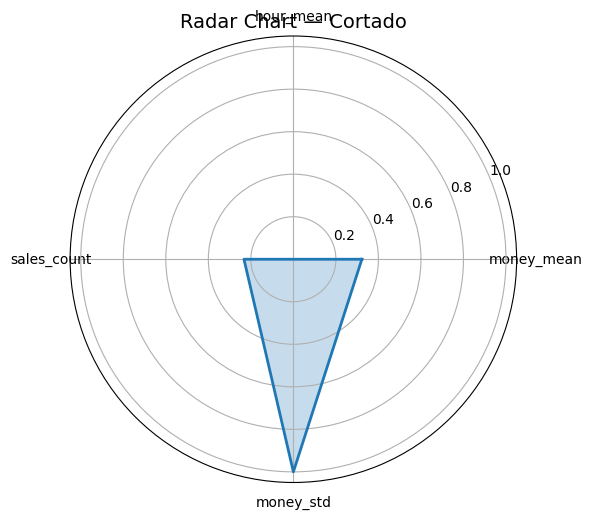

In [ ]:
# 5. Radar Chart — Cortado
values = norm.loc["Cortado"].tolist()
values += values[:1]

plt.figure(figsize=(6,6))
plt.polar(angles, values, linewidth=2)
plt.fill(angles, values, alpha=0.25)
plt.xticks(angles[:-1], labels)
plt.title("Radar Chart — Cortado", size=14)
plt.tight_layout()
plt.show()


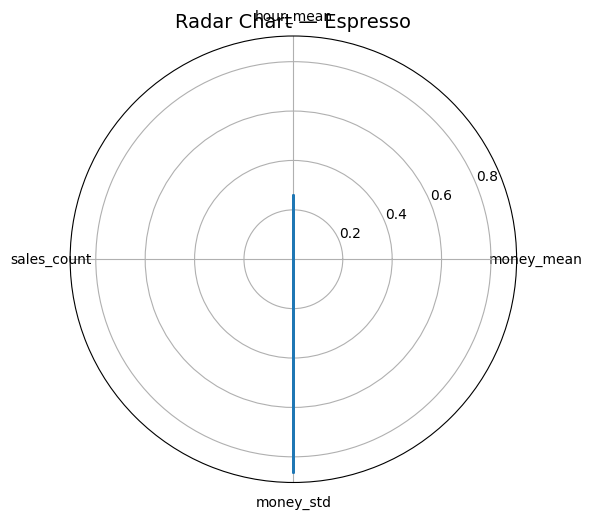

In [ ]:
# 6. Radar Chart — Espresso
values = norm.loc["Espresso"].tolist()
values += values[:1]

plt.figure(figsize=(6,6))
plt.polar(angles, values, linewidth=2)
plt.fill(angles, values, alpha=0.25)
plt.xticks(angles[:-1], labels)
plt.title("Radar Chart — Espresso", size=14)
plt.tight_layout()
plt.show()


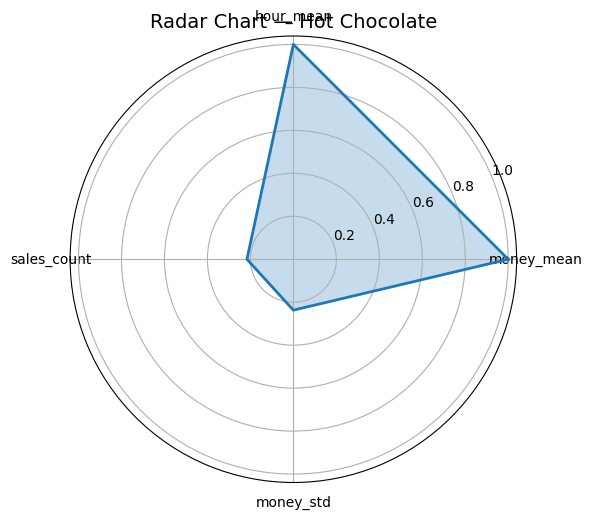

In [ ]:
# 7. Radar Chart — Hot Chocolate
values = norm.loc["Hot Chocolate"].tolist()
values += values[:1]

plt.figure(figsize=(6,6))
plt.polar(angles, values, linewidth=2)
plt.fill(angles, values, alpha=0.25)
plt.xticks(angles[:-1], labels)
plt.title("Radar Chart — Hot Chocolate", size=14)
plt.tight_layout()
plt.show()


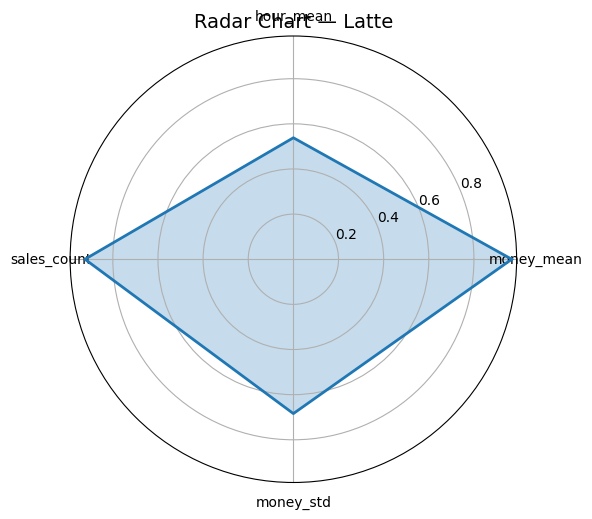

In [ ]:
# 8. Radar Chart — Latte
values = norm.loc["Latte"].tolist()
values += values[:1]

plt.figure(figsize=(6,6))
plt.polar(angles, values, linewidth=2)
plt.fill(angles, values, alpha=0.25)
plt.xticks(angles[:-1], labels)
plt.title("Radar Chart — Latte", size=14)
plt.tight_layout()
plt.show()
